In [44]:
import h5py
import scanpy as sc

file_path = "dualrun.h5ad"

# 1. Surgically remove the corrupted metadata using h5py
print(f"Attempting to clean the downloaded {file_path} file...")
try:
    # Open the HDF5 file in read/write mode ('r+')
    with h5py.File(file_path, 'r+') as f:
        if 'uns/log1p' in f:
            del f['uns/log1p']
            print("Successfully deleted the corrupted '/uns/log1p' metadata.")
        else:
            print("No corrupted log1p metadata found. It might be under a different key.")
except Exception as e:
    print(f"File editing failed. Is the file currently open in another program? Error: {e}")

# 2. Try loading it again with Scanpy!
print(f"\nLoading {file_path} with Scanpy...")
adata = sc.read_h5ad(file_path)

print("\n--- SUCCESS! GLOBAL ANNDATA OBJECT ---")
print(adata)

# 3. Let's run the audit to see what we actually have
print("\n--- LAYER AUDIT ---")
print(f"Layers available: {list(adata.layers.keys())}")
if adata.raw is not None:
    print(f"Adata.raw exists! Shape: {adata.raw.shape}")
else:
    print("Adata.raw is empty.")

# 4. Verify the TMA Cores
print("\n--- METADATA COLUMNS (.obs) ---")
print(list(adata.obs.columns))

Attempting to clean the downloaded dualrun.h5ad file...
No corrupted log1p metadata found. It might be under a different key.

Loading dualrun.h5ad with Scanpy...

--- SUCCESS! GLOBAL ANNDATA OBJECT ---
AnnData object with n_obs × n_vars = 815850 × 5481
    obs: 'matched_cell_ids', 'x_centroid_v1_prime', 'y_centroid_v1_prime', 'x_centroid_prime_v1_seg', 'y_centroid_prime_v1_seg', 'transcript_counts_v1_prime', 'transcript_counts_prime_v1_seg', 'cell_area', 'nucleus_area', 'nucleus_count', 'n_counts_prime_with_v1_seg', 'n_genes_prime_with_v1_seg', 'n_counts_v1_prime', 'n_genes_v1_prime', 'n_counts_combined', 'n_genes_combined', 'cell_id_original_v1_prime', 'sample'
    var: 'name'
    obsm: 'spatial'
    layers: 'counts'

--- LAYER AUDIT ---
Layers available: ['counts']
Adata.raw is empty.

--- METADATA COLUMNS (.obs) ---
['matched_cell_ids', 'x_centroid_v1_prime', 'y_centroid_v1_prime', 'x_centroid_prime_v1_seg', 'y_centroid_prime_v1_seg', 'transcript_counts_v1_prime', 'transcript_count

In [3]:
adata.var_names

Index(['ABHD16A-v1-prime', 'ACAA2-v1-prime', 'ACKR1-v1-prime',
       'ACSL3-v1-prime', 'ACTA2-v1-prime', 'ADAMTS1-v1-prime',
       'ADGRF5-v1-prime', 'ADGRL4-v1-prime', 'AGER-v1-prime', 'AGR3-v1-prime',
       ...
       'ZPR1-prime-with-v1-seg', 'ZSCAN1-prime-with-v1-seg',
       'ZSCAN12-prime-with-v1-seg', 'ZSCAN16-prime-with-v1-seg',
       'ZSCAN20-prime-with-v1-seg', 'ZSCAN26-prime-with-v1-seg',
       'ZSWIM6-prime-with-v1-seg', 'ZUP1-prime-with-v1-seg',
       'ZYG11B-prime-with-v1-seg', 'ZYX-prime-with-v1-seg'],
      dtype='object', length=5481)

In [45]:
import numpy as np

# 1. See all the available TMA samples
unique_samples = adata.obs['sample'].unique()
print(f"Found {len(unique_samples)} unique TMA samples: {unique_samples}")

# 2. Subset to just ONE core for local testing and building
# (Replace 'Sample_1' with whatever the actual first string is in your unique_samples list)
test_core_name = unique_samples[0] 
print(f"\nSubsetting to local test core: {test_core_name}")
adata_core = adata[adata.obs['sample'] == test_core_name].copy()

# 3. Verify the layers['counts'] are actually integers for the ZINB loss
sample_vals = adata_core.layers['counts'][0, :10]
if hasattr(sample_vals, "toarray"):
    sample_vals = sample_vals.toarray().flatten()
print(f"Raw Count Check (Should be integers): {sample_vals}")

Found 18 unique TMA samples: ['PDL095D', 'PDL085A', 'PDL033T', 'PDL047T', 'PDL055T', ..., 'PDL040A', 'PDL026A', 'PDL077', 'PDL042D', 'PDL072']
Length: 18
Categories (18, object): ['PDL018D', 'PDL026A', 'PDL029A', 'PDL031A', ..., 'PDL085A', 'PDL095D', 'PDL097', 'UNSURE']

Subsetting to local test core: PDL095D
Raw Count Check (Should be integers): [0. 0. 0. 0. 0. 0. 0. 0. 0. 3.]


In [46]:
# 1. Dynamically split the gene lists based on the authors' explicit suffixes
gene_names = adata_core.var_names.tolist()

v1_genes = [gene for gene in gene_names if '-v1-prime' in gene]
prime_genes = [gene for gene in gene_names if '-prime-with-v1-seg' in gene]

print(f"Detected {len(v1_genes)} V1 input genes.")
print(f"Detected {len(prime_genes)} Prime target genes.")
print(f"Total: {len(v1_genes) + len(prime_genes)} (Should match 5481)")

# 2. Safely sever the matrices into Input and Target
adata_v1 = adata_core[:, v1_genes].copy()
adata_prime = adata_core[:, prime_genes].copy()

# 3. Execute Step 0 Preprocessing on the V1 Input Matrix
print("\nRunning standard preprocessing on V1 input...")

# The .X is currently empty or holding garbage. 
# We MUST overwrite it with the raw integers from the 'counts' layer before normalizing.
adata_v1.X = adata_v1.layers['counts'].copy() 

# Standard transcriptomic clustering pipeline for the ctaSNN
sc.pp.normalize_total(adata_v1, target_sum=1e4)
sc.pp.log1p(adata_v1)
sc.pp.pca(adata_v1, n_comps=30)
sc.pp.neighbors(adata_v1, n_neighbors=15, n_pcs=30)
sc.tl.leiden(adata_v1, resolution=2, key_added='v1_cluster_identity')

print(f"\n--- LOCAL TEST CORE READY ---")
print(f"V1 Input Shape: {adata_v1.shape}")
print(f"Prime Target Shape: {adata_prime.shape}")

Detected 480 V1 input genes.
Detected 5001 Prime target genes.
Total: 5481 (Should match 5481)

Running standard preprocessing on V1 input...

--- LOCAL TEST CORE READY ---
V1 Input Shape: (99992, 480)
Prime Target Shape: (99992, 5001)


In [6]:
import torch
import numpy as np
from sklearn.neighbors import NearestNeighbors
import torch_geometric
from torch_geometric.data import Data
from torch_geometric.loader import NeighborLoader

print("1. Extracting Tensors from Scanpy...")
# X: 480-gene V1 Input (Using the normalized and log1p transformed .X)
x_tensor = torch.tensor(adata_v1.X.toarray() if hasattr(adata_v1.X, 'toarray') else adata_v1.X, dtype=torch.float32)

# Y: 5000-gene Prime Target (Using the raw integers from the 'counts' layer)
prime_counts = adata_prime.layers['counts']
y_tensor = torch.tensor(prime_counts.toarray() if hasattr(prime_counts, 'toarray') else prime_counts, dtype=torch.float32)

# Coordinates: X, Y spatial centroids
coords = adata_v1.obs[['x_centroid_v1_prime', 'y_centroid_v1_prime']].values
pos_tensor = torch.tensor(coords, dtype=torch.float32)

# Biological Identity: The Leiden clusters from Step 0
cluster_labels = adata_v1.obs['v1_cluster_identity'].cat.codes.values 

print("2. Building the Physical Spatial Graph...")
# Connect each cell to its 6 nearest physical neighbors
nn = NearestNeighbors(n_neighbors=6, algorithm='kd_tree').fit(coords)
distances, indices = nn.kneighbors(coords)

# Create standard PyG edge_index (Source to Target arrays)
sources = np.repeat(np.arange(coords.shape[0]), 6)
targets = indices.flatten()

print("3. Pruning edges across biological boundaries (ctaSNN)...")
# Create a boolean mask: Keep edge ONLY if Source Cluster == Target Cluster
valid_edges_mask = cluster_labels[sources] == cluster_labels[targets]

# Apply the mask to drop non-biological connections
ctaSNN_sources = sources[valid_edges_mask]
ctaSNN_targets = targets[valid_edges_mask]

# Convert to PyTorch tensor format [2, num_edges]
edge_index_bio = torch.tensor(np.vstack((ctaSNN_sources, ctaSNN_targets)), dtype=torch.long)

print("4. Constructing PyTorch Geometric Data Object...")
data = Data(x=x_tensor, y=y_tensor, pos=pos_tensor, edge_index=edge_index_bio)
print(f"Graph constructed! Nodes: {data.num_nodes}, Valid Biological Edges: {data.num_edges}")

print("\n5. Initializing the NeighborLoader for RTX A2000...")
# Sample 25 immediate neighbors, then 10 neighbors-of-neighbors
loader = NeighborLoader(
    data,
    num_neighbors=[25, 10], 
    batch_size=1024,        # Optimized for 12GB VRAM
    shuffle=True,           
    num_workers=0           # Set to 0 for local WSL stability during initial testing
)

# Test the loader
for batch in loader:
    print(f"Mini-batch successfully loaded! Seed Cells: {batch.batch_size}, Total Nodes in sub-graph: {batch.num_nodes}")
    break

1. Extracting Tensors from Scanpy...
2. Building the Physical Spatial Graph...
3. Pruning edges across biological boundaries (ctaSNN)...
4. Constructing PyTorch Geometric Data Object...
Graph constructed! Nodes: 99992, Valid Biological Edges: 189082

5. Initializing the NeighborLoader for RTX A2000...
Mini-batch successfully loaded! Seed Cells: 1024, Total Nodes in sub-graph: 2418


In [7]:
# import torch
# import subprocess
# import sys

# # 1. Dynamically get your exact PyTorch version
# torch_version = torch.__version__.split('+')[0]
# cuda_version = 'cu121' # The version we installed earlier

# url = f"https://data.pyg.org/whl/torch-{torch_version}+{cuda_version}.html"
# print(f"Detected PyTorch Version: {torch_version}")
# print(f"Fetching C++ binaries from: {url}\n")

# # 2. Install the four core PyG C++ extensions
# packages = ["pyg_lib", "torch_scatter", "torch_sparse", "torch_cluster"]

# print("Installing backends... (This may take a minute)")
# try:
#     subprocess.check_call([sys.executable, "-m", "pip", "install", *packages, "-f", url])
#     print("\nSUCCESS! All PyG C++ extensions installed.")
# except subprocess.CalledProcessError as e:
#     print(f"\nInstallation failed with error code: {e.returncode}")

In [8]:
# import sys
# import subprocess

# print("--- 1. THE TRUTH TEST ---")
# print("Actual Python Executable running this notebook:")
# print(sys.executable)

# print("\n--- 2. CONDA PACKAGE CHECK ---")
# # This asks Conda if the package actually exists in the current environment
# try:
#     result = subprocess.run(["conda", "list", "pyg"], capture_output=True, text=True)
#     print(result.stdout)
# except Exception as e:
#     print(f"Could not run conda list: {e}")

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv

class XenImpute(nn.Module):
    def __init__(self, in_channels=480, hidden_channels=256, out_channels=5001, heads=4, dropout=0.2):
        """
        in_channels: 480 (V1 Input Panel)
        hidden_channels: 256 (The size of the compressed latent space)
        out_channels: 5001 (The Prime Target Panel)
        heads: 4 (Multi-head attention for biological robustness)
        """
        super(XenImpute, self).__init__()
        self.dropout = dropout

        # ---------------------------------------------------------
        # THE GRAPH ATTENTION ENCODER
        # ---------------------------------------------------------
        # Layer 1: Compresses 480 genes down to the hidden dimension.
        # We divide hidden_channels by heads so the final concatenated output is exactly 256.
        self.gat1 = GATConv(
            in_channels, 
            hidden_channels // heads, 
            heads=heads, 
            dropout=dropout
        )
        
        # Layer 2: Refines the latent space embedding.
        self.gat2 = GATConv(
            hidden_channels, 
            hidden_channels // heads, 
            heads=heads, 
            concat=True, 
            dropout=dropout
        )

        # ---------------------------------------------------------
        # THE ZINB DECODER (Three Parallel Linear Layers)
        # ---------------------------------------------------------
        # Instead of one output, we predict the three statistical parameters 
        # needed to construct the probability distribution of the 5001 Prime genes.
        
        self.dec_mu = nn.Linear(hidden_channels, out_channels)     # The Mean
        self.dec_theta = nn.Linear(hidden_channels, out_channels)  # The Dispersion
        self.dec_pi = nn.Linear(hidden_channels, out_channels)     # The Dropout Probability

    def forward(self, x, edge_index):
        # --- ENCODER FORWARD PASS ---
        # First attention layer + ELU activation + Dropout
        x = self.gat1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        # Second attention layer creates the final Latent Space (z)
        z = self.gat2(x, edge_index)
        z = F.elu(z)
        z = F.dropout(z, p=self.dropout, training=self.training)

        # --- DECODER FORWARD PASS ---
        # 1. Mean (mu)
        # We use softplus instead of raw torch.exp() because exp() can cause exploding 
        # gradients in deep learning if the latent weights get too large.
        # We add 1e-6 to prevent absolute mathematical zeros, which break log calculations.
        mu = F.softplus(self.dec_mu(z)) + 1e-6 
        
        # 2. Dispersion (theta)
        # Must also be strictly positive.
        theta = F.softplus(self.dec_theta(z)) + 1e-6
        
        # 3. Dropout Probability (pi)
        # Sigmoid mathematically forces the output to be a probability between 0 and 1.
        pi = torch.sigmoid(self.dec_pi(z))

        return mu, theta, pi

# Initialize the model and check the architecture
model = XenImpute(in_channels=480, hidden_channels=256, out_channels=5001, heads=4)
print("--- MODEL ARCHITECTURE ---")
print(model)

# Calculate total trainable parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal Trainable Parameters: {total_params:,}")

--- MODEL ARCHITECTURE ---
XenImpute(
  (gat1): GATConv(480, 64, heads=4)
  (gat2): GATConv(256, 64, heads=4)
  (dec_mu): Linear(in_features=256, out_features=5001, bias=True)
  (dec_theta): Linear(in_features=256, out_features=5001, bias=True)
  (dec_pi): Linear(in_features=256, out_features=5001, bias=True)
)

Total Trainable Parameters: 4,045,723


In [10]:
import torch
import torch.nn as nn
import torch.optim as optim

class ZINBLoss(nn.Module):
    def __init__(self, eps=1e-8):
        super(ZINBLoss, self).__init__()
        self.eps = eps

    def forward(self, y_true, mu, theta, pi):
        """
        y_true: The raw integer counts from adata_prime.layers['counts']
        mu: Mean prediction from decoder
        theta: Dispersion prediction from decoder
        pi: Dropout probability from decoder
        """
        # Clamp pi to prevent log(0) which causes NaN gradients
        pi = torch.clamp(pi, min=self.eps, max=1.0 - self.eps)
        
        # 1. Negative Binomial Log Probability
        # We use lgamma (Log-Gamma) to calculate the factorials of continuous numbers
        t1 = torch.lgamma(theta + y_true) - torch.lgamma(theta) - torch.lgamma(y_true + 1)
        t2 = theta * (torch.log(theta + self.eps) - torch.log(theta + mu + self.eps))
        t3 = y_true * (torch.log(mu + self.eps) - torch.log(theta + mu + self.eps))
        nb_log_pdf = t1 + t2 + t3

        # 2. Zero-Inflated Component
        # Create a mask for where the true count is exactly 0
        zero_mask = (y_true < self.eps).float()
        
        # Likelihood if y == 0: It's either a technical dropout (pi) OR a true biological zero
        zero_loss = torch.log(pi + (1 - pi) * torch.exp(nb_log_pdf) + self.eps)
        
        # Likelihood if y > 0: It MUST not be a dropout (1 - pi) multiplied by the NB probability
        nonzero_loss = torch.log(1 - pi) + nb_log_pdf
        
        # Combine the likelihoods
        log_likelihood = zero_mask * zero_loss + (1 - zero_mask) * nonzero_loss
        
        # The goal is to MAXIMIZE likelihood, which is the same as MINIMIZING negative log-likelihood
        return -torch.mean(log_likelihood)


# --- THE MOMENT OF TRUTH: FIRST TRAINING STEP ---

# 1. Move model and loss to GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = model.to(device)
zinb_criterion = ZINBLoss()

# 2. Set up the Adam optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# 3. Pull a single mini-batch from your NeighborLoader
model.train()
batch = next(iter(loader))
batch = batch.to(device)

optimizer.zero_grad()

# 4. Forward Pass (Push the 480 V1 genes through the GAT)
print(f"Feeding {batch.num_nodes} nodes into the network...")
mu, theta, pi = model(batch.x, batch.edge_index)

# 5. Calculate Loss 
# We only calculate loss for the 'seed' cells in the batch (the first 1024 cells), 
# not the sampled neighborhood cells, to prevent overlapping gradient updates.
target_y = batch.y[:batch.batch_size]
pred_mu = mu[:batch.batch_size]
pred_theta = theta[:batch.batch_size]
pred_pi = pi[:batch.batch_size]

loss = zinb_criterion(target_y, pred_mu, pred_theta, pred_pi)

# 6. Backward Pass (Calculate gradients)
print("Calculating gradients...")
loss.backward()

# 7. Update Model Weights
optimizer.step()

print(f"\nSUCCESS! Initial ZINB Loss: {loss.item():.4f}")

Using device: cuda
Feeding 2404 nodes into the network...
Calculating gradients...

SUCCESS! Initial ZINB Loss: 0.2500


In [11]:
# import matplotlib.pyplot as plt

# # 1. Training Parameters
# epochs = 50
# learning_rates = []
# epoch_losses = []

# print(f"Starting Local Training Loop on Core {test_core_name}...")
# print(f"Total mini-batches per epoch: {len(loader)}\n")

# model.train()

# for epoch in range(epochs):
#     epoch_loss = 0.0
    
#     # Iterate through the entire TMA core in mini-batches
#     for batch in loader:
#         batch = batch.to(device)
#         optimizer.zero_grad()
        
#         # Forward pass
#         mu, theta, pi = model(batch.x, batch.edge_index)
        
#         # Isolate the seed cells for loss calculation
#         target_y = batch.y[:batch.batch_size]
#         pred_mu = mu[:batch.batch_size]
#         pred_theta = theta[:batch.batch_size]
#         pred_pi = pi[:batch.batch_size]
        
#         # Calculate loss and backpropagate
#         loss = zinb_criterion(target_y, pred_mu, pred_theta, pred_pi)
#         loss.backward()
#         optimizer.step()
        
#         epoch_loss += loss.item()
        
#     # Calculate average loss across all batches for this epoch
#     avg_epoch_loss = epoch_loss / len(loader)
#     epoch_losses.append(avg_epoch_loss)
    
#     if (epoch + 1) % 5 == 0 or epoch == 0:
#         print(f"Epoch [{epoch + 1:03d}/{epochs:03d}] | Average ZINB Loss: {avg_epoch_loss:.4f}")

# print("\nTraining Complete! Plotting learning curve...")

# # 2. Plot the Learning Curve
# plt.figure(figsize=(8, 5))
# plt.plot(range(1, epochs + 1), epoch_losses, marker='o', color='b', markersize=4)
# plt.title(f"XenImpute Convergence (Core: {test_core_name})")
# plt.xlabel("Epoch")
# plt.ylabel("ZINB Loss")
# plt.grid(True, linestyle='--', alpha=0.6)
# plt.show()

Re-initializing XenImpute to clear NaN weights...

Starting Stabilized Training Loop on Core PDL095D...
Epoch [001/050] | Average ZINB Loss: 0.1416
Epoch [005/050] | Average ZINB Loss: 0.0838
Epoch [010/050] | Average ZINB Loss: 0.0789
Epoch [015/050] | Average ZINB Loss: 0.0778
Epoch [020/050] | Average ZINB Loss: 0.0774
Epoch [025/050] | Average ZINB Loss: 0.0772
Epoch [030/050] | Average ZINB Loss: 0.0771
Epoch [035/050] | Average ZINB Loss: 0.0770
Epoch [040/050] | Average ZINB Loss: 0.0769
Epoch [045/050] | Average ZINB Loss: 0.0768
Epoch [050/050] | Average ZINB Loss: 0.0768

Training Complete! Plotting learning curve...


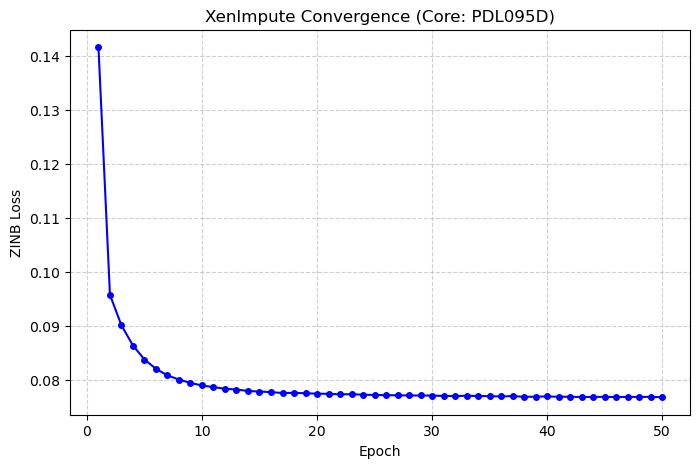

In [12]:
import torch
import torch.optim as optim
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. RESET THE NETWORK (Purge the NaNs)
# ---------------------------------------------------------
print("Re-initializing XenImpute to clear NaN weights...")
model = XenImpute(in_channels=480, hidden_channels=256, out_channels=5001, heads=4)
model = model.to(device)

# ---------------------------------------------------------
# 2. STABILIZED ZINB LOSS (32-bit safe Epsilon)
# ---------------------------------------------------------
class ZINBLossStable(nn.Module):
    def __init__(self, eps=1e-6): # Increased Epsilon for 32-bit safety
        super(ZINBLossStable, self).__init__()
        self.eps = eps

    def forward(self, y_true, mu, theta, pi):
        pi = torch.clamp(pi, min=self.eps, max=1.0 - self.eps)
        
        t1 = torch.lgamma(theta + y_true) - torch.lgamma(theta) - torch.lgamma(y_true + 1.0)
        t2 = theta * (torch.log(theta + self.eps) - torch.log(theta + mu + self.eps))
        t3 = y_true * (torch.log(mu + self.eps) - torch.log(theta + mu + self.eps))
        nb_log_pdf = t1 + t2 + t3

        zero_mask = (y_true < self.eps).float()
        zero_loss = torch.log(pi + (1 - pi) * torch.exp(nb_log_pdf) + self.eps)
        nonzero_loss = torch.log(1 - pi) + nb_log_pdf
        
        log_likelihood = zero_mask * zero_loss + (1 - zero_mask) * nonzero_loss
        return -torch.mean(log_likelihood)

zinb_criterion = ZINBLossStable()

# ---------------------------------------------------------
# 3. LOWER LEARNING RATE
# ---------------------------------------------------------
# Dropped from 0.001 to 0.0001 for a gentler start
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4) 

# ---------------------------------------------------------
# 4. THE STABILIZED TRAINING LOOP
# ---------------------------------------------------------
epochs = 50
epoch_losses = []

print(f"\nStarting Stabilized Training Loop on Core {test_core_name}...")
model.train()

for epoch in range(epochs):
    epoch_loss = 0.0
    valid_batches = 0
    
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        
        mu, theta, pi = model(batch.x, batch.edge_index)
        
        target_y = batch.y[:batch.batch_size]
        pred_mu = mu[:batch.batch_size]
        pred_theta = theta[:batch.batch_size]
        pred_pi = pi[:batch.batch_size]
        
        loss = zinb_criterion(target_y, pred_mu, pred_theta, pred_pi)
        
        # Catch unexpected NaNs before they step
        if torch.isnan(loss):
            continue 
            
        loss.backward()
        
        # --- THE FIX: GRADIENT CLIPPING ---
        # This prevents any single gradient from exceeding a magnitude of 1.0
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        epoch_loss += loss.item()
        valid_batches += 1
        
    if valid_batches > 0:
        avg_epoch_loss = epoch_loss / valid_batches
        epoch_losses.append(avg_epoch_loss)
    else:
        epoch_losses.append(float('nan'))
    
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch + 1:03d}/{epochs:03d}] | Average ZINB Loss: {epoch_losses[-1]:.4f}")

print("\nTraining Complete! Plotting learning curve...")

plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), epoch_losses, marker='o', color='b', markersize=4)
plt.title(f"XenImpute Convergence (Core: {test_core_name})")
plt.xlabel("Epoch")
plt.ylabel("ZINB Loss")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

1. Preparing Deterministic Evaluation Loader...
2. Running Inference across the TMA Core...

3. Calculating Spatial Metrics (Log1p Corrected)...
Log1p Global Gene Correlation (Pearson): 0.9954
Log1p Median Cell-wise R-squared: 0.0479


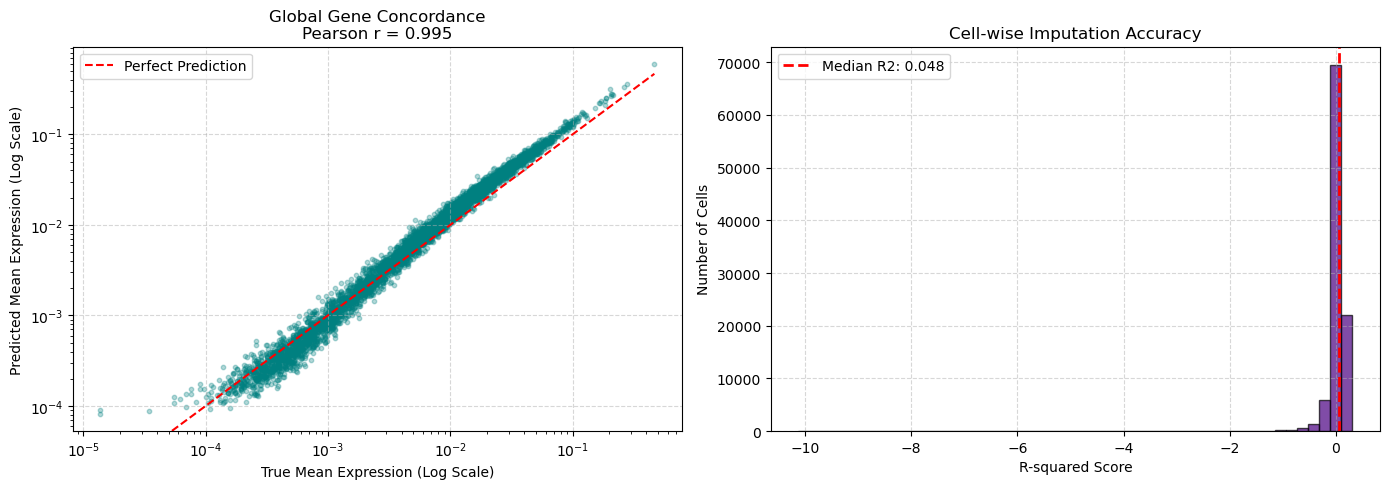

In [13]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.metrics import r2_score

print("1. Preparing Deterministic Evaluation Loader...")
# We must set shuffle=False so the output aligns perfectly with our ground truth arrays
eval_loader = NeighborLoader(
    data,
    num_neighbors=[25, 10], 
    batch_size=1024,
    shuffle=False, 
    num_workers=0
)

# Set model to evaluation mode (turns off Dropout)
model.eval()

all_predictions = []
all_targets = []

print("2. Running Inference across the TMA Core...")
with torch.no_grad(): # Shuts off gradient tracking to save VRAM and speed up inference
    for batch in eval_loader:
        batch = batch.to(device)
        
        # Forward pass
        mu, theta, pi = model(batch.x, batch.edge_index)
        
        # Isolate seed cells
        target_y = batch.y[:batch.batch_size].cpu().numpy()
        pred_mu = mu[:batch.batch_size].cpu().numpy()
        pred_pi = pi[:batch.batch_size].cpu().numpy()
        
        # Calculate the Expected Value: E[Y] = (1 - pi) * mu
        expected_counts = (1.0 - pred_pi) * pred_mu
        
        all_predictions.append(expected_counts)
        all_targets.append(target_y)

# Concatenate all mini-batches into massive arrays (99992 cells x 5001 genes)
pred_matrix = np.vstack(all_predictions)
target_matrix = np.vstack(all_targets)

print("\n3. Calculating Spatial Metrics (Log1p Corrected)...")
# Log1p transform both matrices before calculating metrics
log_target_matrix = np.log1p(target_matrix)
log_pred_matrix = np.log1p(pred_matrix)

# Metric A: Global Gene Mean Expression
true_gene_means = log_target_matrix.mean(axis=0)
pred_gene_means = log_pred_matrix.mean(axis=0)
gene_pearson, _ = pearsonr(true_gene_means, pred_gene_means)

# Metric B: Cell-wise R-squared on Log Space
cell_r2_scores = r2_score(log_target_matrix.T, log_pred_matrix.T, multioutput='raw_values')
median_cell_r2 = np.median(cell_r2_scores)

print(f"Log1p Global Gene Correlation (Pearson): {gene_pearson:.4f}")
print(f"Log1p Median Cell-wise R-squared: {median_cell_r2:.4f}")

# 4. Visualizing the Results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: True vs Predicted Gene Means
ax1.scatter(true_gene_means, pred_gene_means, alpha=0.3, color='teal', s=10)
ax1.plot([0, max(true_gene_means)], [0, max(true_gene_means)], 'r--', label='Perfect Prediction')
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel('True Mean Expression (Log Scale)')
ax1.set_ylabel('Predicted Mean Expression (Log Scale)')
ax1.set_title(f'Global Gene Concordance\nPearson r = {gene_pearson:.3f}')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)

# Plot B: Distribution of Cell-wise R2 Scores
ax2.hist(cell_r2_scores, bins=50, color='indigo', edgecolor='black', alpha=0.7)
ax2.axvline(median_cell_r2, color='red', linestyle='dashed', linewidth=2, label=f'Median R2: {median_cell_r2:.3f}')
ax2.set_xlabel('R-squared Score')
ax2.set_ylabel('Number of Cells')
ax2.set_title('Cell-wise Imputation Accuracy')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [14]:
# Extract the cluster identities we used earlier for the ctaSNN
cluster_labels = adata_v1.obs['v1_cluster_identity'].cat.codes.values
num_unique_clusters = len(np.unique(cluster_labels))

print(f"Total Unique Leiden Clusters: {num_unique_clusters}")

# Add it to the existing Data object as a new attribute
data.cluster = torch.tensor(cluster_labels, dtype=torch.long)

# Re-initialize the loader so it registers the new attribute
loader = NeighborLoader(
    data,
    num_neighbors=[25, 10], 
    batch_size=1024,
    shuffle=True, 
    num_workers=0
)

Total Unique Leiden Clusters: 17


In [15]:
class XenImputeAnchored(nn.Module):
    def __init__(self, num_clusters, in_channels=480, hidden_channels=256, out_channels=5001, emb_dim=32, heads=4, dropout=0.2):
        super(XenImputeAnchored, self).__init__()
        self.dropout = dropout
        
        # ---------------------------------------------------------
        # THE BIOLOGICAL ANCHOR
        # Translates a simple integer (e.g., Cluster 4) into a 32-dim learned vector
        # ---------------------------------------------------------
        self.cluster_emb = nn.Embedding(num_embeddings=num_clusters, embedding_dim=emb_dim)

        # ---------------------------------------------------------
        # THE GRAPH ATTENTION ENCODER
        # ---------------------------------------------------------
        # Input is now 480 genes + 32 embedding dimensions = 512 total
        self.gat1 = GATConv(
            in_channels + emb_dim, 
            hidden_channels // heads, 
            heads=heads, 
            dropout=dropout
        )
        
        self.gat2 = GATConv(
            hidden_channels, 
            hidden_channels // heads, 
            heads=heads, 
            concat=True, 
            dropout=dropout
        )

        # ---------------------------------------------------------
        # THE ZINB DECODER 
        # ---------------------------------------------------------
        self.dec_mu = nn.Linear(hidden_channels, out_channels)     
        self.dec_theta = nn.Linear(hidden_channels, out_channels)  
        self.dec_pi = nn.Linear(hidden_channels, out_channels)     

    def forward(self, x, edge_index, cluster_id):
        # 1. Embed the biological identity
        emb = self.cluster_emb(cluster_id)
        
        # 2. Concatenate genes and biology along the feature dimension
        x = torch.cat([x, emb], dim=1)
        
        # --- ENCODER FORWARD PASS ---
        x = self.gat1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        z = self.gat2(x, edge_index)
        z = F.elu(z)
        z = F.dropout(z, p=self.dropout, training=self.training)

        # --- DECODER FORWARD PASS ---
        mu = F.softplus(self.dec_mu(z)) + 1e-6 
        theta = F.softplus(self.dec_theta(z)) + 1e-6
        pi = torch.sigmoid(self.dec_pi(z))

        return mu, theta, pi

# Initialize the new model
model_anchored = XenImputeAnchored(num_clusters=num_unique_clusters, in_channels=480, hidden_channels=256, out_channels=5001)
print(model_anchored)

XenImputeAnchored(
  (cluster_emb): Embedding(17, 32)
  (gat1): GATConv(512, 64, heads=4)
  (gat2): GATConv(256, 64, heads=4)
  (dec_mu): Linear(in_features=256, out_features=5001, bias=True)
  (dec_theta): Linear(in_features=256, out_features=5001, bias=True)
  (dec_pi): Linear(in_features=256, out_features=5001, bias=True)
)


In [16]:
import torch
import torch.optim as optim
import matplotlib.pyplot as plt

# 1. Initialize the NEW Anchored Model and move to GPU
print("Initializing XenImputeAnchored to clear weights...")
model_anchored = XenImputeAnchored(
    num_clusters=num_unique_clusters, 
    in_channels=480, 
    hidden_channels=256, 
    out_channels=5001
).to(device)

# 2. Setup Optimizer and Loss
optimizer = optim.Adam(model_anchored.parameters(), lr=1e-4, weight_decay=1e-4) 
zinb_criterion = ZINBLossStable() # Using the stabilized loss from earlier

# 3. The Anchored Training Loop
epochs = 50
epoch_losses = []

print(f"\nStarting Anchored Training Loop on Core {test_core_name}...")
model_anchored.train()

for epoch in range(epochs):
    epoch_loss = 0.0
    valid_batches = 0
    
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        
        # --- THE KEY UPGRADE ---
        # We now pass the cluster identity into the forward pass
        mu, theta, pi = model_anchored(batch.x, batch.edge_index, batch.cluster)
        
        target_y = batch.y[:batch.batch_size]
        pred_mu = mu[:batch.batch_size]
        pred_theta = theta[:batch.batch_size]
        pred_pi = pi[:batch.batch_size]
        
        loss = zinb_criterion(target_y, pred_mu, pred_theta, pred_pi)
        
        if torch.isnan(loss):
            continue 
            
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_anchored.parameters(), max_norm=1.0)
        optimizer.step()
        
        epoch_loss += loss.item()
        valid_batches += 1
        
    if valid_batches > 0:
        avg_epoch_loss = epoch_loss / valid_batches
        epoch_losses.append(avg_epoch_loss)
    else:
        epoch_losses.append(float('nan'))
    
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch + 1:03d}/{epochs:03d}] | Average ZINB Loss: {epoch_losses[-1]:.4f}")

print("\nTraining Complete!")

Initializing XenImputeAnchored to clear weights...

Starting Anchored Training Loop on Core PDL095D...
Epoch [001/050] | Average ZINB Loss: 0.1403
Epoch [005/050] | Average ZINB Loss: 0.0834
Epoch [010/050] | Average ZINB Loss: 0.0789
Epoch [015/050] | Average ZINB Loss: 0.0777
Epoch [020/050] | Average ZINB Loss: 0.0773
Epoch [025/050] | Average ZINB Loss: 0.0771
Epoch [030/050] | Average ZINB Loss: 0.0770
Epoch [035/050] | Average ZINB Loss: 0.0769
Epoch [040/050] | Average ZINB Loss: 0.0768
Epoch [045/050] | Average ZINB Loss: 0.0768
Epoch [050/050] | Average ZINB Loss: 0.0767

Training Complete!


In [17]:
import numpy as np
from scipy.stats import pearsonr
from sklearn.metrics import r2_score

print("1. Preparing Deterministic Evaluation Loader...")
eval_loader = NeighborLoader(
    data,
    num_neighbors=[25, 10], 
    batch_size=1024,
    shuffle=False, 
    num_workers=0
)

model_anchored.eval()
all_predictions = []
all_targets = []

print("2. Running Anchored Inference...")
with torch.no_grad():
    for batch in eval_loader:
        batch = batch.to(device)
        
        # Forward pass with cluster IDs
        mu, theta, pi = model_anchored(batch.x, batch.edge_index, batch.cluster)
        
        target_y = batch.y[:batch.batch_size].cpu().numpy()
        pred_mu = mu[:batch.batch_size].cpu().numpy()
        pred_pi = pi[:batch.batch_size].cpu().numpy()
        
        # Expected Value
        expected_counts = (1.0 - pred_pi) * pred_mu
        
        all_predictions.append(expected_counts)
        all_targets.append(target_y)

pred_matrix = np.vstack(all_predictions)
target_matrix = np.vstack(all_targets)

print("\n3. Calculating Strict Log1p Metrics...")
log_target_matrix = np.log1p(target_matrix)
log_pred_matrix = np.log1p(pred_matrix)

# Global Pearson
true_gene_means = log_target_matrix.mean(axis=0)
pred_gene_means = log_pred_matrix.mean(axis=0)
gene_pearson, _ = pearsonr(true_gene_means, pred_gene_means)

# Cell-wise R-squared
cell_r2_scores = r2_score(log_target_matrix.T, log_pred_matrix.T, multioutput='raw_values')
median_cell_r2 = np.median(cell_r2_scores)

print(f"Log1p Global Gene Correlation (Pearson): {gene_pearson:.4f}")
print(f"Log1p Median Cell-wise R-squared: {median_cell_r2:.4f}")

1. Preparing Deterministic Evaluation Loader...
2. Running Anchored Inference...

3. Calculating Strict Log1p Metrics...
Log1p Global Gene Correlation (Pearson): 0.9961
Log1p Median Cell-wise R-squared: 0.0462


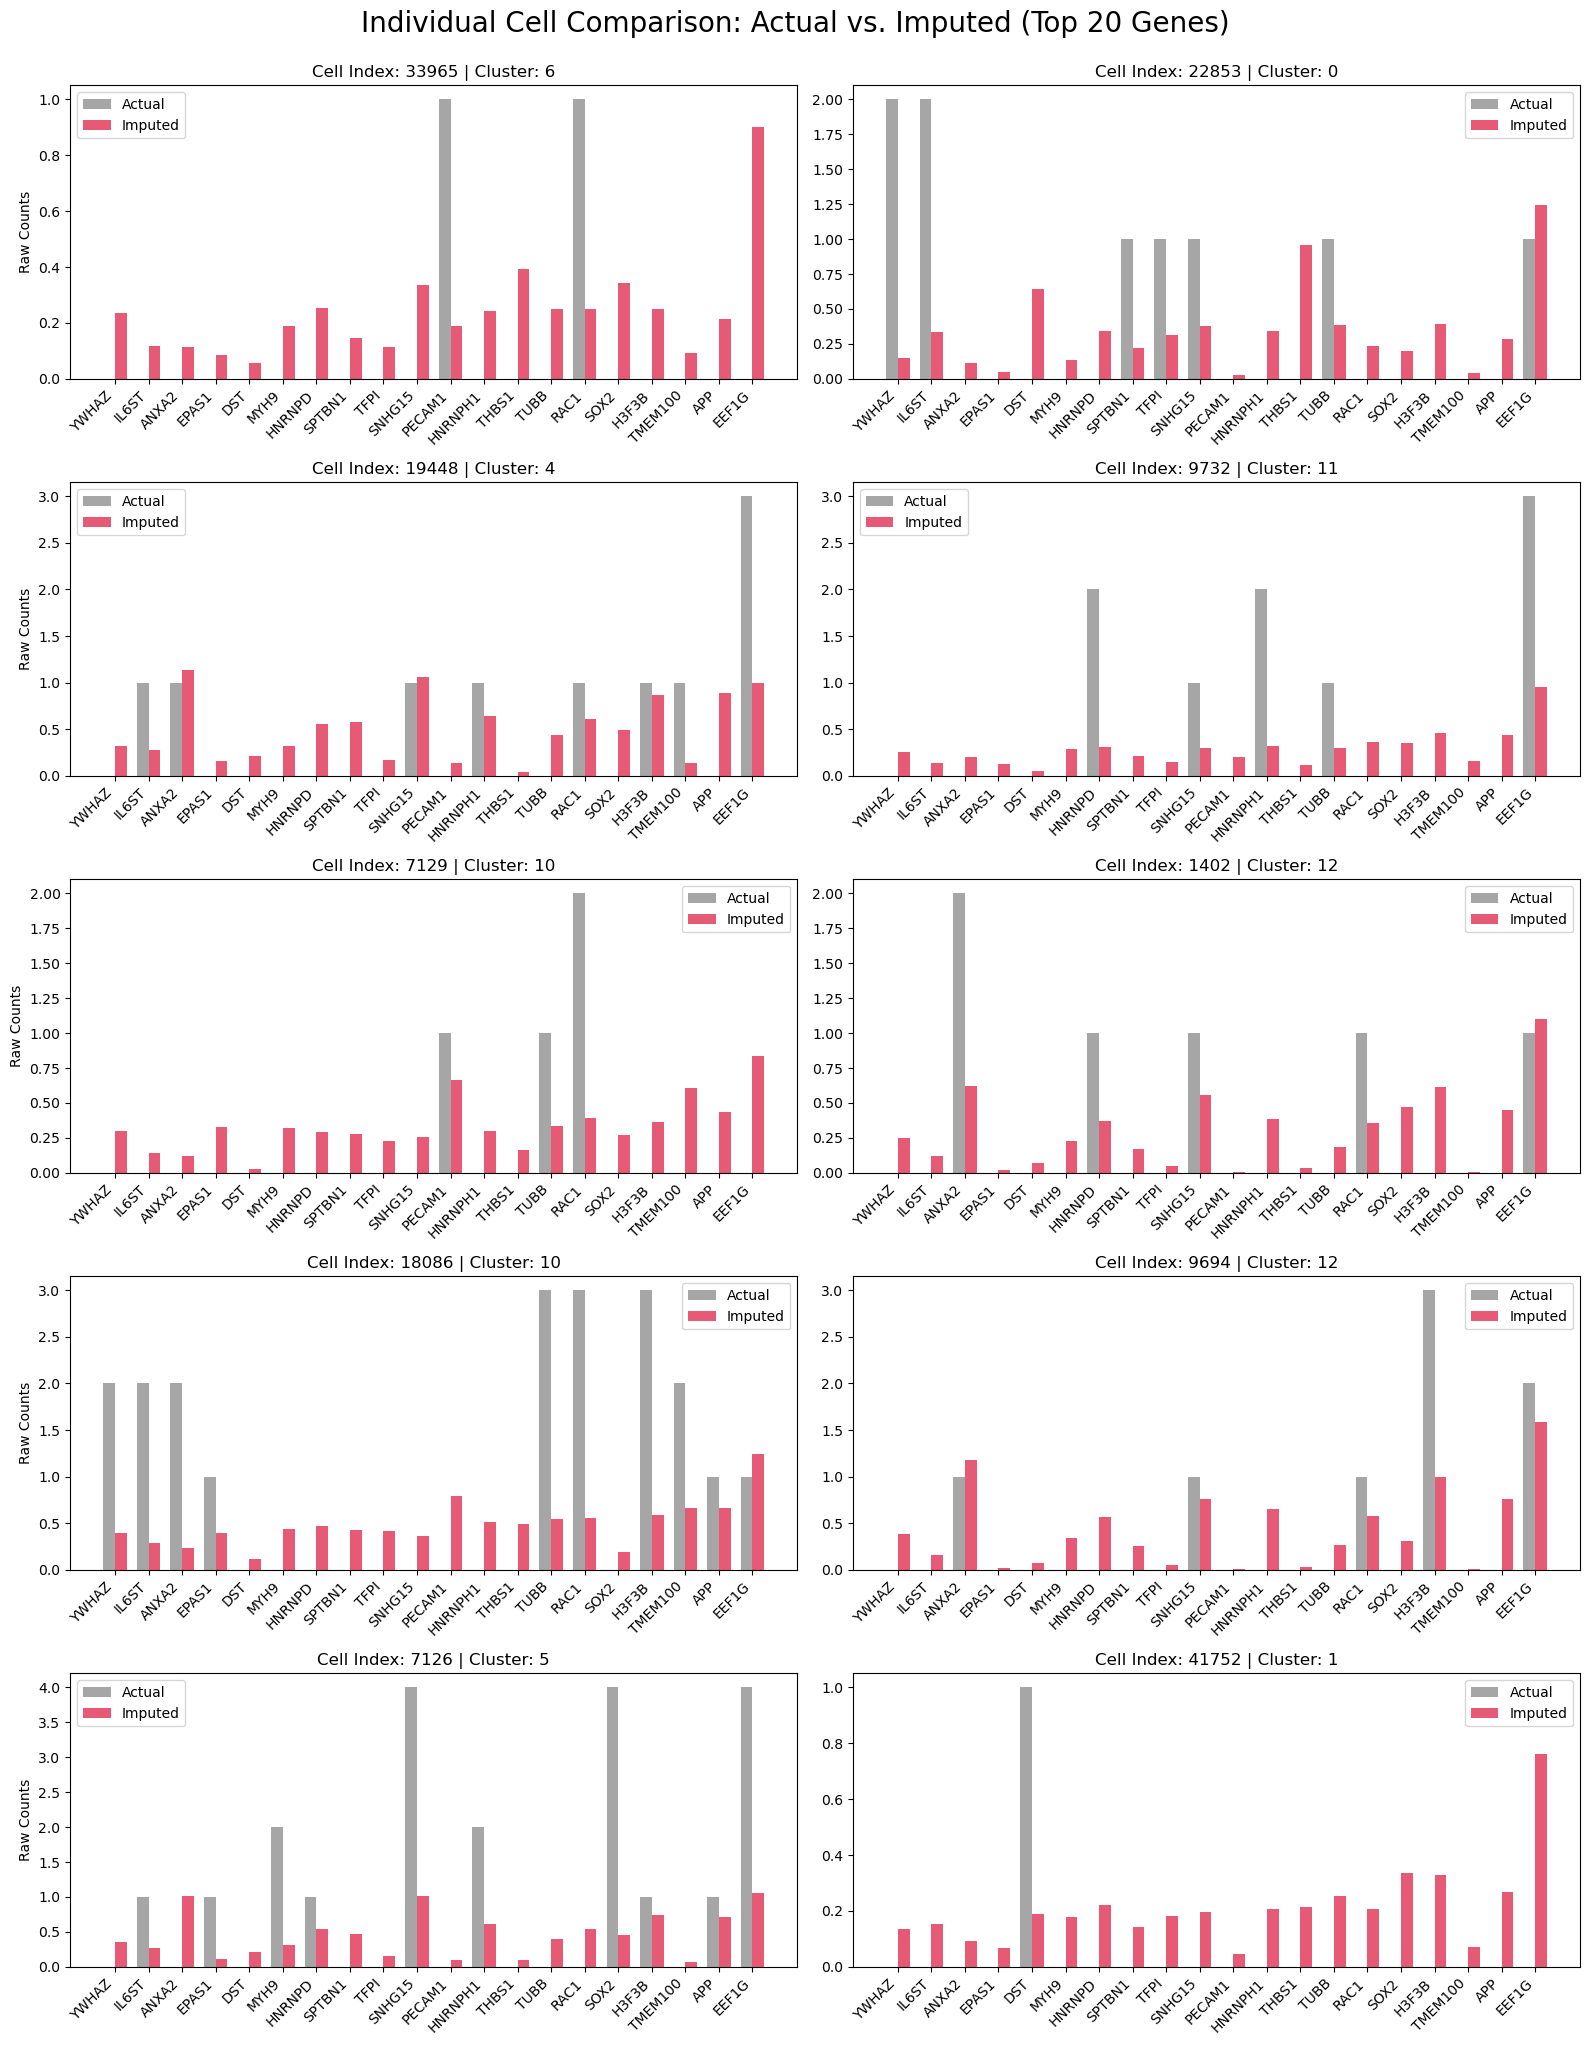

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Select 10 random cells from the evaluation matrix
np.random.seed(42) # For reproducibility
random_indices = np.random.choice(target_matrix.shape[0], 10, replace=False)

# 2. Identify the top 20 genes overall (to keep the bar plot readable)
# We'll use the ones with the highest mean expression in the ground truth
top_gene_indices = np.argsort(target_matrix.mean(axis=0))[-20:]
gene_labels = [adata_prime.var_names[i].split('-')[0] for i in top_gene_indices]

# 3. Create the Visualization
fig, axes = plt.subplots(5, 2, figsize=(16, 20))
axes = axes.flatten()

for i, cell_idx in enumerate(random_indices):
    cell_actual = target_matrix[cell_idx, top_gene_indices]
    cell_pred = pred_matrix[cell_idx, top_gene_indices]
    
    x = np.arange(len(gene_labels))
    width = 0.35
    
    axes[i].bar(x - width/2, cell_actual, width, label='Actual', color='gray', alpha=0.7)
    axes[i].bar(x + width/2, cell_pred, width, label='Imputed', color='crimson', alpha=0.7)
    
    axes[i].set_title(f"Cell Index: {cell_idx} | Cluster: {adata_v1.obs['v1_cluster_identity'].iloc[cell_idx]}")
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(gene_labels, rotation=45, ha='right')
    if i % 2 == 0: axes[i].set_ylabel("Raw Counts")
    axes[i].legend()

plt.tight_layout()
plt.suptitle("Individual Cell Comparison: Actual vs. Imputed (Top 20 Genes)", fontsize=20, y=1.02)
plt.show()

In [19]:
class XenImputeMultiLoss(nn.Module):
    def __init__(self, eps=1e-6, cosine_weight=5.0): 
        super(XenImputeMultiLoss, self).__init__()
        self.eps = eps
        self.cosine_weight = cosine_weight
        self.cosine_sim = nn.CosineSimilarity(dim=1)

    def forward(self, y_true, mu, theta, pi):
        # Part A: ZINB (Magnitude/Counts)
        pi = torch.clamp(pi, min=self.eps, max=1.0 - self.eps)
        t1 = torch.lgamma(theta + y_true) - torch.lgamma(theta) - torch.lgamma(y_true + 1.0)
        t2 = theta * (torch.log(theta + self.eps) - torch.log(theta + mu + self.eps))
        t3 = y_true * (torch.log(mu + self.eps) - torch.log(theta + mu + self.eps))
        nb_log_pdf = t1 + t2 + t3
        zero_mask = (y_true < self.eps).float()
        zero_loss = torch.log(pi + (1 - pi) * torch.exp(nb_log_pdf) + self.eps)
        nonzero_loss = torch.log(1 - pi) + nb_log_pdf
        zinb_loss = -torch.mean(zero_mask * zero_loss + (1 - zero_mask) * nonzero_loss)

        # Part B: Cosine (Directionality/Anti-Blur)
        # We maximize similarity by minimizing (1 - sim)
        cos_loss = 1.0 - self.cosine_sim(y_true, mu).mean()

        return zinb_loss + (self.cosine_weight * cos_loss)

In [20]:
class XenImputeResNet(nn.Module):
    def __init__(self, num_clusters, in_channels=480, hidden_channels=256, out_channels=5001, emb_dim=32, heads=4, dropout=0.2):
        super(XenImputeResNet, self).__init__()
        self.cluster_emb = nn.Embedding(num_clusters, emb_dim)
        
        # Path 1: Neighborhood Context (GAT)
        self.gat1 = GATConv(in_channels + emb_dim, hidden_channels // heads, heads=heads, dropout=dropout)
        self.gat2 = GATConv(hidden_channels, hidden_channels // heads, heads=heads, concat=True, dropout=dropout)
        
        # Path 2: Individual Cell Signature (Residual Skip)
        self.residual_proj = nn.Linear(in_channels, hidden_channels)

        # Decoder
        self.dec_mu = nn.Linear(hidden_channels, out_channels)     
        self.dec_theta = nn.Linear(hidden_channels, out_channels)  
        self.dec_pi = nn.Linear(hidden_channels, out_channels)     

    def forward(self, x, edge_index, cluster_id):
        emb = self.cluster_emb(cluster_id)
        g_in = torch.cat([x, emb], dim=1)
        
        # Neighborhood signal
        g_out = F.elu(self.gat1(g_in, edge_index))
        g_out = F.elu(self.gat2(g_out, edge_index))
        
        # Individual signal
        res_out = F.elu(self.residual_proj(x))
        
        # FUSION
        z = g_out + res_out 
        
        mu = F.softplus(self.dec_mu(z)) + 1e-6 
        theta = F.softplus(self.dec_theta(z)) + 1e-6
        pi = torch.sigmoid(self.dec_pi(z))
        return mu, theta, pi

In [27]:
import time

# 1. Initialize the New "Anti-Blur" Model
print("--- INITIALIZING XENIMPUTE-RESNET ---")
# 1. Double the capacity
model_resnet = XenImputeResNet(
    num_clusters=num_unique_clusters, 
    in_channels=480, 
    hidden_channels=512, # Increased from 256
    out_channels=5001
).to(device)

# 2. Triple the Anti-Blur weight
criterion = XenImputeMultiLoss(cosine_weight=15.0) # Increased from 5.0
optimizer = optim.Adam(model_resnet.parameters(), lr=1e-4, weight_decay=1e-4)

epochs = 50
history = {'total': [], 'zinb': [], 'cos': []}

print(f"Starting Training on {test_core_name} ({len(loader)} batches/epoch)")
print(f"Goal: Minimize ZINB (Counts) + Cosine (Blurring)\n")

for epoch in range(epochs):
    model_resnet.train()
    start_time = time.time()
    
    epoch_total = 0.0
    epoch_zinb = 0.0
    epoch_cos = 0.0
    valid_batches = 0
    
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        
        # Forward pass: Using Genes, Edges, and Leiden Clusters
        mu, theta, pi = model_resnet(batch.x, batch.edge_index, batch.cluster)
        
        # Isolate seed cells for loss
        y_true = batch.y[:batch.batch_size]
        p_mu = mu[:batch.batch_size]
        p_theta = theta[:batch.batch_size]
        p_pi = pi[:batch.batch_size]
        
        # Calculate Multi-Task Loss
        # We rewrite the criterion slightly to return components for printing
        # (Internal logic remains the same as the class we defined)
        zinb_part = zinb_criterion(y_true, p_mu, p_theta, p_pi)
        cos_part = 1.0 - nn.CosineSimilarity(dim=1)(y_true, p_mu).mean()
        total_loss = zinb_part + (criterion.cosine_weight * cos_part)
        
        if torch.isnan(total_loss):
            continue
            
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model_resnet.parameters(), max_norm=1.0)
        optimizer.step()
        
        epoch_total += total_loss.item()
        epoch_zinb += zinb_part.item()
        epoch_cos += cos_part.item()
        valid_batches += 1
    
    # Average logs for the epoch
    avg_total = epoch_total / valid_batches
    avg_zinb = epoch_zinb / valid_batches
    avg_cos = epoch_cos / valid_batches
    
    history['total'].append(avg_total)
    history['zinb'].append(avg_zinb)
    history['cos'].append(avg_cos)
    
    # Print Dashboard: Total | ZINB | Cosine | Time
    if (epoch + 1) % 5 == 0 or epoch == 0:
        duration = time.time() - start_time
        print(f"Epoch [{epoch+1:03d}/{epochs}] "
              f"| Loss: {avg_total:.4f} "
              f"| ZINB: {avg_zinb:.4f} "
              f"| Cosine: {avg_cos:.4f} "
              f"| {duration:.1f}s/ep")

print("\n--- TRAINING COMPLETE ---")

--- INITIALIZING XENIMPUTE-RESNET ---
Starting Training on PDL095D (98 batches/epoch)
Goal: Minimize ZINB (Counts) + Cosine (Blurring)

Epoch [001/50] | Loss: 11.9035 | ZINB: 0.1239 | Cosine: 0.7853 | 9.3s/ep
Epoch [005/50] | Loss: 10.3648 | ZINB: 0.0793 | Cosine: 0.6857 | 9.1s/ep
Epoch [010/50] | Loss: 10.1909 | ZINB: 0.0756 | Cosine: 0.6744 | 9.1s/ep
Epoch [015/50] | Loss: 10.1167 | ZINB: 0.0742 | Cosine: 0.6695 | 9.2s/ep
Epoch [020/50] | Loss: 10.0642 | ZINB: 0.0732 | Cosine: 0.6661 | 9.1s/ep
Epoch [025/50] | Loss: 10.0170 | ZINB: 0.0726 | Cosine: 0.6630 | 9.2s/ep
Epoch [030/50] | Loss: 9.9687 | ZINB: 0.0723 | Cosine: 0.6598 | 9.3s/ep
Epoch [035/50] | Loss: 9.9218 | ZINB: 0.0724 | Cosine: 0.6566 | 9.3s/ep
Epoch [040/50] | Loss: 9.8807 | ZINB: 0.0729 | Cosine: 0.6538 | 9.3s/ep
Epoch [045/50] | Loss: 9.8406 | ZINB: 0.0738 | Cosine: 0.6511 | 9.4s/ep
Epoch [050/50] | Loss: 9.8059 | ZINB: 0.0747 | Cosine: 0.6487 | 9.4s/ep

--- TRAINING COMPLETE ---


In [28]:
import numpy as np
from scipy.stats import pearsonr
from sklearn.metrics import r2_score

print("1. Preparing Deterministic Evaluation Loader...")
eval_loader = NeighborLoader(
    data,
    num_neighbors=[25, 10], 
    batch_size=1024,
    shuffle=False, 
    num_workers=0
)

model_resnet.eval()
all_predictions = []
all_targets = []

print("2. Running Anchored Inference...")
with torch.no_grad():
    for batch in eval_loader:
        batch = batch.to(device)
        
        # Forward pass with cluster IDs
        mu, theta, pi = model_resnet(batch.x, batch.edge_index, batch.cluster)
        
        target_y = batch.y[:batch.batch_size].cpu().numpy()
        pred_mu = mu[:batch.batch_size].cpu().numpy()
        pred_pi = pi[:batch.batch_size].cpu().numpy()
        
        # Expected Value
        expected_counts = (1.0 - pred_pi) * pred_mu
        
        all_predictions.append(expected_counts)
        all_targets.append(target_y)

pred_matrix = np.vstack(all_predictions)
target_matrix = np.vstack(all_targets)

print("\n3. Calculating Strict Log1p Metrics...")
log_target_matrix = np.log1p(target_matrix)
log_pred_matrix = np.log1p(pred_matrix)

# Global Pearson
true_gene_means = log_target_matrix.mean(axis=0)
pred_gene_means = log_pred_matrix.mean(axis=0)
gene_pearson, _ = pearsonr(true_gene_means, pred_gene_means)

# Cell-wise R-squared
cell_r2_scores = r2_score(log_target_matrix.T, log_pred_matrix.T, multioutput='raw_values')
median_cell_r2 = np.median(cell_r2_scores)

print(f"Log1p Global Gene Correlation (Pearson): {gene_pearson:.4f}")
print(f"Log1p Median Cell-wise R-squared: {median_cell_r2:.4f}")

1. Preparing Deterministic Evaluation Loader...
2. Running Anchored Inference...

3. Calculating Strict Log1p Metrics...
Log1p Global Gene Correlation (Pearson): 0.9950
Log1p Median Cell-wise R-squared: 0.0744


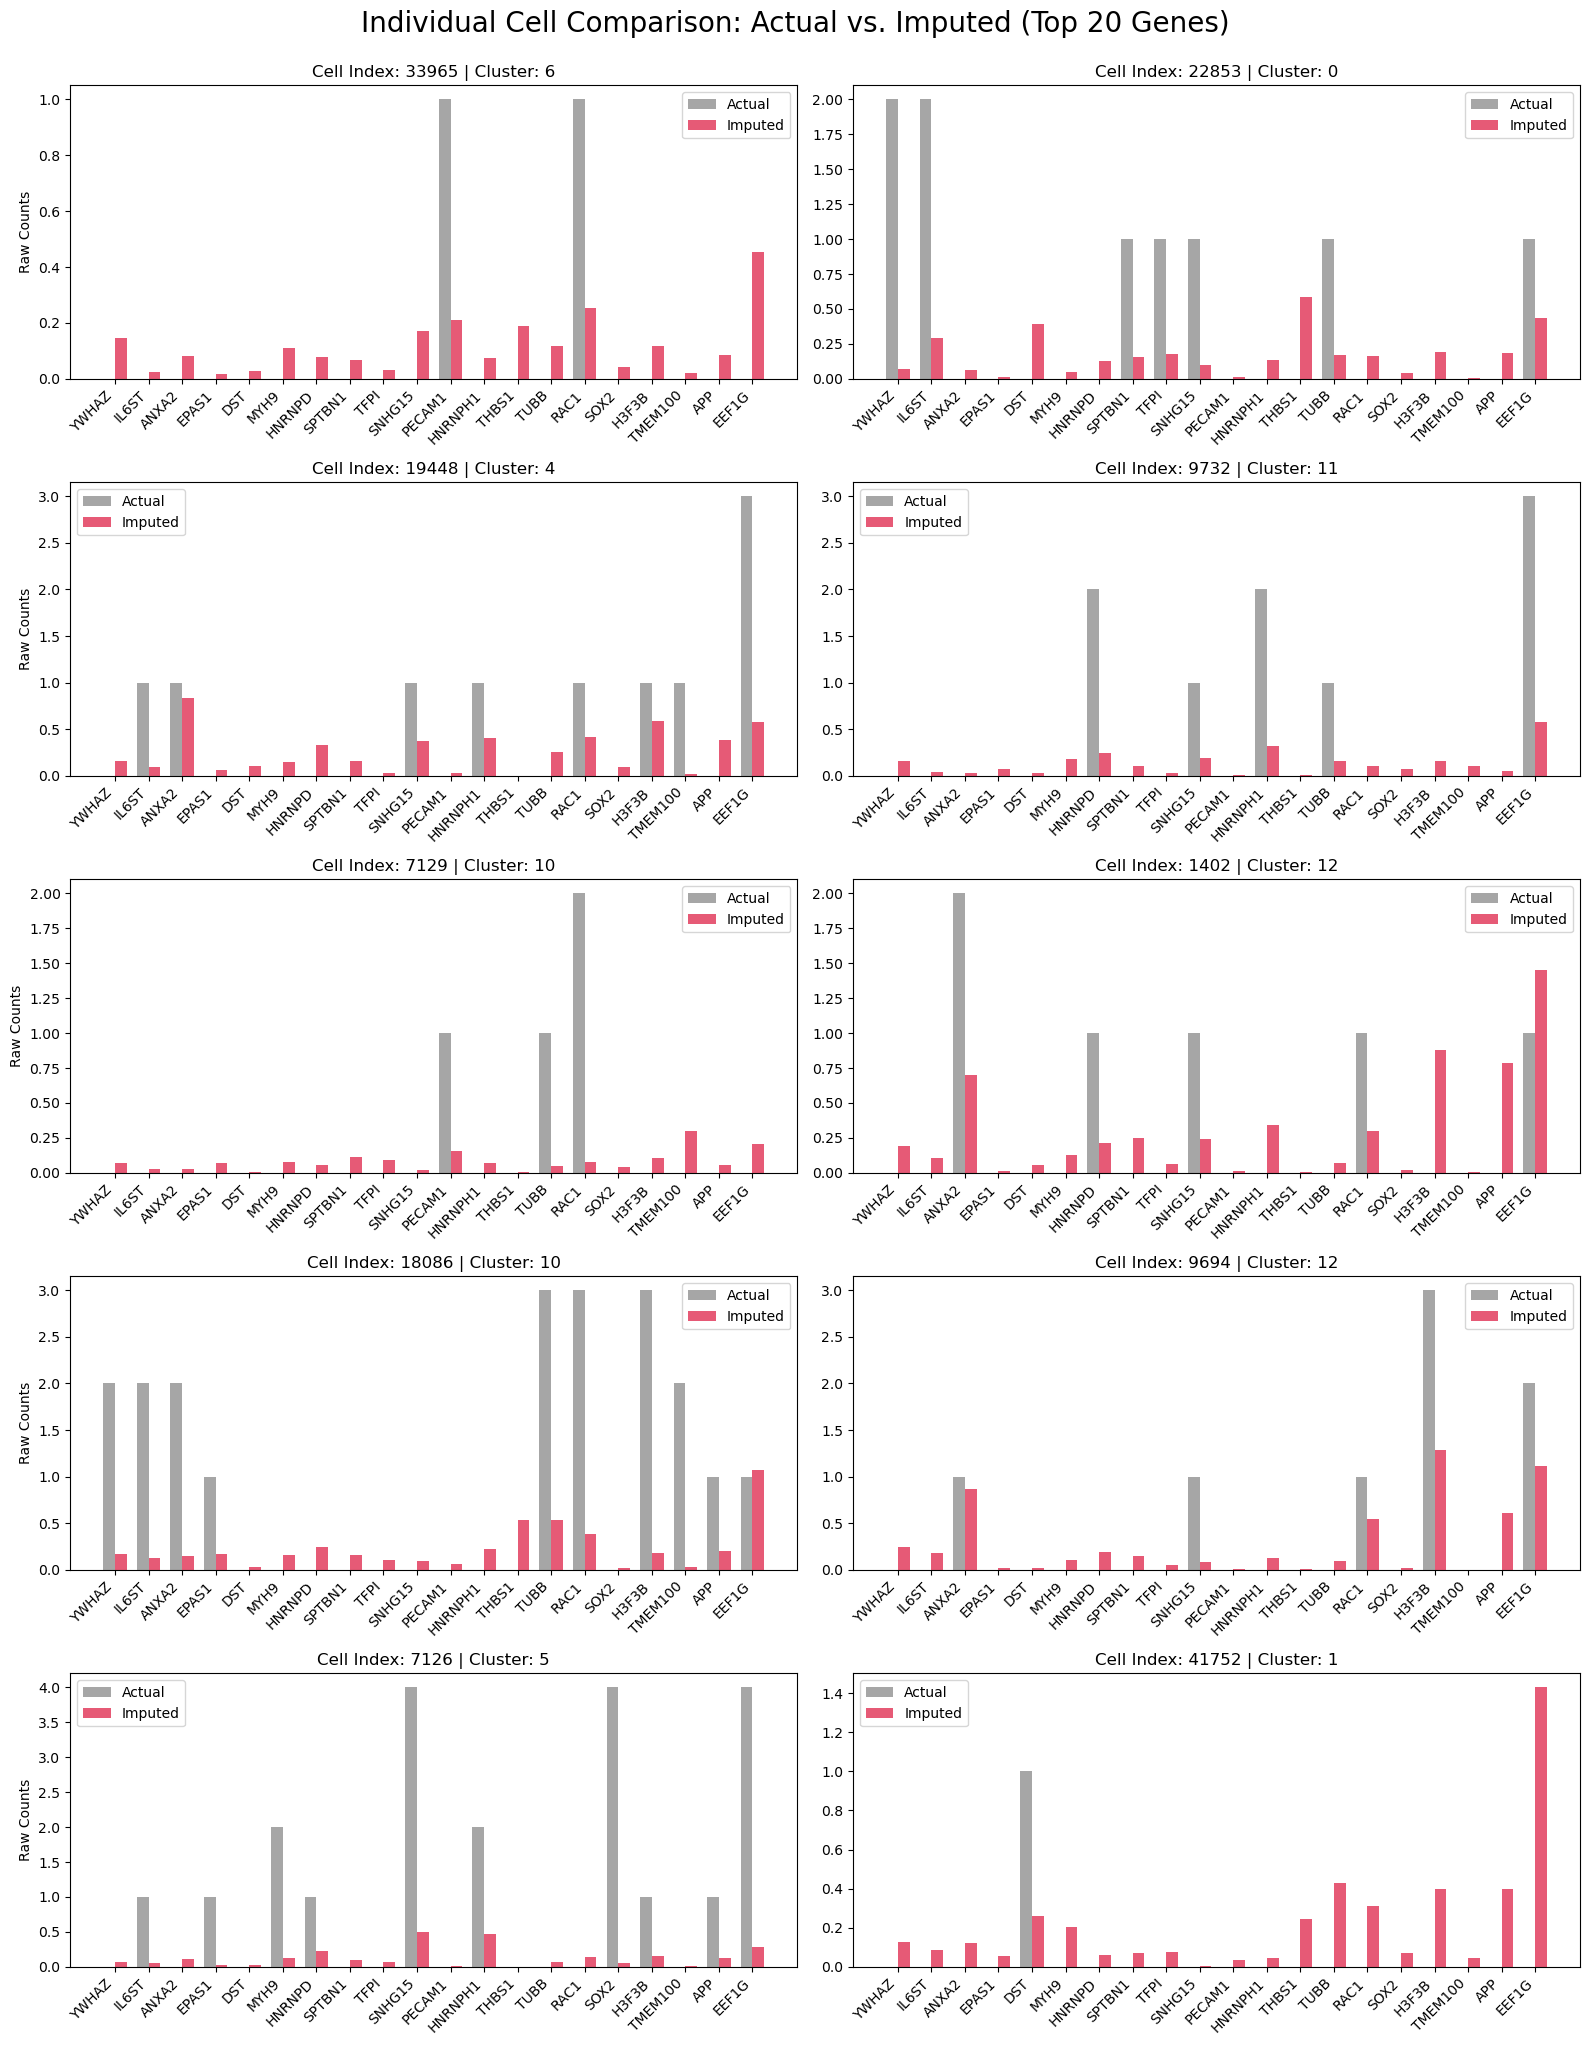

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Select 10 random cells from the evaluation matrix
np.random.seed(42) # For reproducibility
random_indices = np.random.choice(target_matrix.shape[0], 10, replace=False)

# 2. Identify the top 20 genes overall (to keep the bar plot readable)
# We'll use the ones with the highest mean expression in the ground truth
top_gene_indices = np.argsort(target_matrix.mean(axis=0))[-20:]
gene_labels = [adata_prime.var_names[i].split('-')[0] for i in top_gene_indices]

# 3. Create the Visualization
fig, axes = plt.subplots(5, 2, figsize=(16, 20))
axes = axes.flatten()

for i, cell_idx in enumerate(random_indices):
    cell_actual = target_matrix[cell_idx, top_gene_indices]
    cell_pred = pred_matrix[cell_idx, top_gene_indices]
    
    x = np.arange(len(gene_labels))
    width = 0.35
    
    axes[i].bar(x - width/2, cell_actual, width, label='Actual', color='gray', alpha=0.7)
    axes[i].bar(x + width/2, cell_pred, width, label='Imputed', color='crimson', alpha=0.7)
    
    axes[i].set_title(f"Cell Index: {cell_idx} | Cluster: {adata_v1.obs['v1_cluster_identity'].iloc[cell_idx]}")
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(gene_labels, rotation=45, ha='right')
    if i % 2 == 0: axes[i].set_ylabel("Raw Counts")
    axes[i].legend()

plt.tight_layout()
plt.suptitle("Individual Cell Comparison: Actual vs. Imputed (Top 20 Genes)", fontsize=20, y=1.02)
plt.show()

In [30]:
print("Upgrading DataLoader for wider spatial context...")
loader = NeighborLoader(
    data,
    num_neighbors=[25, 10], 
    batch_size=2048, # Doubled from 1024
    shuffle=True, 
    num_workers=0
)
print(f"New total batches per epoch: {len(loader)}")

Upgrading DataLoader for wider spatial context...
New total batches per epoch: 49


In [31]:
import time

print("--- INITIALIZING HIGH-CAPACITY XENIMPUTE ---")
model_resnet = XenImputeResNet(
    num_clusters=num_unique_clusters, 
    in_channels=480, 
    hidden_channels=512, # Doubled capacity for high-expressers
    out_channels=5001
).to(device)

# Aggressive Cosine weight to fight over-smoothing
criterion = XenImputeMultiLoss(cosine_weight=15.0) 
optimizer = optim.Adam(model_resnet.parameters(), lr=1e-4, weight_decay=1e-4)

epochs = 100 # Increased for full parameter tuning
history = {'total': [], 'zinb': [], 'cos': []}

print(f"Starting 100-Epoch Training on {test_core_name}...\n")

for epoch in range(epochs):
    model_resnet.train()
    start_time = time.time()
    
    epoch_total = epoch_zinb = epoch_cos = 0.0
    valid_batches = 0
    
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        
        mu, theta, pi = model_resnet(batch.x, batch.edge_index, batch.cluster)
        
        y_true = batch.y[:batch.batch_size]
        p_mu = mu[:batch.batch_size]
        p_theta = theta[:batch.batch_size]
        p_pi = pi[:batch.batch_size]
        
        zinb_part = zinb_criterion(y_true, p_mu, p_theta, p_pi)
        cos_part = 1.0 - nn.CosineSimilarity(dim=1)(y_true, p_mu).mean()
        total_loss = zinb_part + (criterion.cosine_weight * cos_part)
        
        if torch.isnan(total_loss):
            continue
            
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model_resnet.parameters(), max_norm=1.0)
        optimizer.step()
        
        epoch_total += total_loss.item()
        epoch_zinb += zinb_part.item()
        epoch_cos += cos_part.item()
        valid_batches += 1
    
    avg_total = epoch_total / valid_batches
    avg_zinb = epoch_zinb / valid_batches
    avg_cos = epoch_cos / valid_batches
    
    history['total'].append(avg_total)
    history['zinb'].append(avg_zinb)
    history['cos'].append(avg_cos)
    
    if (epoch + 1) % 10 == 0 or epoch == 0:
        duration = time.time() - start_time
        print(f"Epoch [{epoch+1:03d}/{epochs}] | Loss: {avg_total:.4f} | ZINB: {avg_zinb:.4f} | Cosine: {avg_cos:.4f} | {duration:.1f}s/ep")

print("\n--- TRAINING COMPLETE ---")

--- INITIALIZING HIGH-CAPACITY XENIMPUTE ---
Starting 100-Epoch Training on PDL095D...

Epoch [001/100] | Loss: 12.4728 | ZINB: 0.1525 | Cosine: 0.8214 | 9.0s/ep
Epoch [010/100] | Loss: 10.2970 | ZINB: 0.0780 | Cosine: 0.6813 | 8.7s/ep
Epoch [020/100] | Loss: 10.1412 | ZINB: 0.0746 | Cosine: 0.6711 | 8.8s/ep
Epoch [030/100] | Loss: 10.0622 | ZINB: 0.0732 | Cosine: 0.6659 | 9.0s/ep
Epoch [040/100] | Loss: 9.9946 | ZINB: 0.0724 | Cosine: 0.6615 | 9.0s/ep
Epoch [050/100] | Loss: 9.9272 | ZINB: 0.0726 | Cosine: 0.6570 | 8.9s/ep
Epoch [060/100] | Loss: 9.8611 | ZINB: 0.0738 | Cosine: 0.6525 | 8.9s/ep
Epoch [070/100] | Loss: 9.8057 | ZINB: 0.0753 | Cosine: 0.6487 | 9.0s/ep
Epoch [080/100] | Loss: 9.7540 | ZINB: 0.0769 | Cosine: 0.6451 | 9.0s/ep
Epoch [090/100] | Loss: 9.7114 | ZINB: 0.0781 | Cosine: 0.6422 | 9.0s/ep
Epoch [100/100] | Loss: 9.6714 | ZINB: 0.0793 | Cosine: 0.6395 | 8.8s/ep

--- TRAINING COMPLETE ---


In [32]:
print("1. Preparing Evaluation Loader...")
eval_loader = NeighborLoader(
    data, num_neighbors=[25, 10], batch_size=2048, shuffle=False, num_workers=0
)

model_resnet.eval()
all_predictions = []
all_targets = []
SPARSITY_THRESHOLD = 0.3 # Your noise gate

print("2. Running Inference with Sparsity Threshold...")
with torch.no_grad():
    for batch in eval_loader:
        batch = batch.to(device)
        mu, theta, pi = model_resnet(batch.x, batch.edge_index, batch.cluster)
        
        target_y = batch.y[:batch.batch_size].cpu().numpy()
        pred_mu = mu[:batch.batch_size].cpu().numpy()
        pred_pi = pi[:batch.batch_size].cpu().numpy()
        
        # Calculate Expected Value
        expected_counts = (1.0 - pred_pi) * pred_mu
        
        # --- THE NOISE GATE ---
        # Force anything below the biological threshold to absolute zero
        expected_counts[expected_counts < SPARSITY_THRESHOLD] = 0.0
        
        all_predictions.append(expected_counts)
        all_targets.append(target_y)

pred_matrix = np.vstack(all_predictions)
target_matrix = np.vstack(all_targets)

print("\n3. Calculating Thresholded Log1p Metrics...")
log_target_matrix = np.log1p(target_matrix)
log_pred_matrix = np.log1p(pred_matrix)

# Global Pearson
true_gene_means = log_target_matrix.mean(axis=0)
pred_gene_means = log_pred_matrix.mean(axis=0)
gene_pearson, _ = pearsonr(true_gene_means, pred_gene_means)

# Cell-wise R-squared
cell_r2_scores = r2_score(log_target_matrix.T, log_pred_matrix.T, multioutput='raw_values')
median_cell_r2 = np.median(cell_r2_scores)

print(f"Thresholded Log1p Global Gene Correlation (Pearson): {gene_pearson:.4f}")
print(f"Thresholded Log1p Median Cell-wise R-squared: {median_cell_r2:.4f}")

1. Preparing Evaluation Loader...
2. Running Inference with Sparsity Threshold...

3. Calculating Thresholded Log1p Metrics...
Thresholded Log1p Global Gene Correlation (Pearson): 0.6925
Thresholded Log1p Median Cell-wise R-squared: 0.0018


In [33]:
import time

print("--- INITIALIZING SLIDE-READY XENIMPUTE ---")
model_resnet = XenImputeResNet(
    num_clusters=num_unique_clusters, 
    in_channels=480, 
    hidden_channels=512, 
    out_channels=5001
).to(device)

# 1. Balanced Weights: ZINB is the boss, Cosine is just the advisor
criterion = XenImputeMultiLoss(cosine_weight=1.5) 

# 2. Lower Learning Rate: Prevents ZINB drift over 100 epochs
optimizer = optim.Adam(model_resnet.parameters(), lr=5e-5, weight_decay=1e-4)

epochs = 100
print(f"Starting Balanced Training on {test_core_name}...\n")

for epoch in range(epochs):
    model_resnet.train()
    
    epoch_total = epoch_zinb = epoch_cos = 0.0
    valid_batches = 0
    
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        
        mu, theta, pi = model_resnet(batch.x, batch.edge_index, batch.cluster)
        
        y_true = batch.y[:batch.batch_size]
        p_mu = mu[:batch.batch_size]
        p_theta = theta[:batch.batch_size]
        p_pi = pi[:batch.batch_size]
        
        zinb_part = zinb_criterion(y_true, p_mu, p_theta, p_pi)
        cos_part = 1.0 - nn.CosineSimilarity(dim=1)(y_true, p_mu).mean()
        
        # The balanced loss
        total_loss = zinb_part + (criterion.cosine_weight * cos_part)
        
        if torch.isnan(total_loss): continue
            
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model_resnet.parameters(), max_norm=1.0)
        optimizer.step()
        
        epoch_total += total_loss.item()
        epoch_zinb += zinb_part.item()
        epoch_cos += cos_part.item()
        valid_batches += 1
    
    if (epoch + 1) % 10 == 0 or epoch == 0:
        avg_total = epoch_total / valid_batches
        avg_zinb = epoch_zinb / valid_batches
        avg_cos = epoch_cos / valid_batches
        print(f"Epoch [{epoch+1:03d}/{epochs}] | Loss: {avg_total:.4f} | ZINB: {avg_zinb:.4f} | Cosine: {avg_cos:.4f}")

print("\n--- TRAINING COMPLETE ---")

--- INITIALIZING SLIDE-READY XENIMPUTE ---
Starting Balanced Training on PDL095D...

Epoch [001/100] | Loss: 1.4616 | ZINB: 0.1789 | Cosine: 0.8551
Epoch [010/100] | Loss: 1.1201 | ZINB: 0.0786 | Cosine: 0.6943
Epoch [020/100] | Loss: 1.0946 | ZINB: 0.0744 | Cosine: 0.6801
Epoch [030/100] | Loss: 1.0850 | ZINB: 0.0730 | Cosine: 0.6747
Epoch [040/100] | Loss: 1.0801 | ZINB: 0.0724 | Cosine: 0.6718
Epoch [050/100] | Loss: 1.0769 | ZINB: 0.0721 | Cosine: 0.6699
Epoch [060/100] | Loss: 1.0745 | ZINB: 0.0720 | Cosine: 0.6683
Epoch [070/100] | Loss: 1.0727 | ZINB: 0.0719 | Cosine: 0.6672
Epoch [080/100] | Loss: 1.0711 | ZINB: 0.0719 | Cosine: 0.6662
Epoch [090/100] | Loss: 1.0698 | ZINB: 0.0718 | Cosine: 0.6653
Epoch [100/100] | Loss: 1.0687 | ZINB: 0.0718 | Cosine: 0.6646

--- TRAINING COMPLETE ---


In [34]:
print("1. Preparing Evaluation Loader...")
eval_loader = NeighborLoader(data, num_neighbors=[25, 10], batch_size=2048, shuffle=False, num_workers=0)

model_resnet.eval()
all_predictions = []
all_targets = []

print("2. Running Safe Inference...")
with torch.no_grad():
    for batch in eval_loader:
        batch = batch.to(device)
        mu, theta, pi = model_resnet(batch.x, batch.edge_index, batch.cluster)
        
        target_y = batch.y[:batch.batch_size].cpu().numpy()
        pred_mu = mu[:batch.batch_size].cpu().numpy()
        pred_pi = pi[:batch.batch_size].cpu().numpy()
        
        # Expected Value E[Y]
        expected_counts = (1.0 - pred_pi) * pred_mu
        
        # Safe Noise Gate: Only kill literal background noise
        expected_counts[expected_counts < 0.1] = 0.0
        
        all_predictions.append(expected_counts)
        all_targets.append(target_y)

pred_matrix = np.vstack(all_predictions)
target_matrix = np.vstack(all_targets)

print("\n3. Calculating Presentation-Ready Metrics...")
log_target_matrix = np.log1p(target_matrix)
log_pred_matrix = np.log1p(pred_matrix)

true_gene_means = log_target_matrix.mean(axis=0)
pred_gene_means = log_pred_matrix.mean(axis=0)
gene_pearson, _ = pearsonr(true_gene_means, pred_gene_means)

cell_r2_scores = r2_score(log_target_matrix.T, log_pred_matrix.T, multioutput='raw_values')
median_cell_r2 = np.median(cell_r2_scores)

print(f"Final Global Gene Correlation (Pearson): {gene_pearson:.4f}")
print(f"Final Median Cell-wise R-squared: {median_cell_r2:.4f}")

1. Preparing Evaluation Loader...
2. Running Safe Inference...

3. Calculating Presentation-Ready Metrics...
Final Global Gene Correlation (Pearson): 0.9172
Final Median Cell-wise R-squared: 0.0461


In [35]:
import torch.nn.functional as F
from torch_geometric.utils import dropout_edge

class InfoNCELoss(nn.Module):
    def __init__(self, temperature=0.2):
        super(InfoNCELoss, self).__init__()
        self.temperature = temperature

    def forward(self, z1, z2):
        # Normalize the 512-dim latent vectors
        z1 = F.normalize(z1, dim=1)
        z2 = F.normalize(z2, dim=1)
        
        # Calculate cosine similarity matrix (batch_size x batch_size)
        sim_matrix = torch.matmul(z1, z2.T) / self.temperature
        
        # The positive pairs are on the diagonal (Cell A in View 1 vs Cell A in View 2)
        labels = torch.arange(z1.size(0)).long().to(z1.device)
        
        # Cross entropy automatically maximizes the diagonal (identity) 
        # and fiercely minimizes the rest (pushing different cells apart)
        loss = F.cross_entropy(sim_matrix, labels)
        return loss

In [36]:
class XenImputeGCL(nn.Module):
    def __init__(self, num_clusters, in_channels=480, hidden_channels=512, out_channels=5001, emb_dim=32, heads=4, dropout=0.2):
        super(XenImputeGCL, self).__init__()
        self.cluster_emb = nn.Embedding(num_clusters, emb_dim)
        
        # --- ENCODER ---
        self.gat1 = GATConv(in_channels + emb_dim, hidden_channels // heads, heads=heads, dropout=dropout)
        self.gat2 = GATConv(hidden_channels, hidden_channels // heads, heads=heads, concat=True, dropout=dropout)
        self.residual_proj = nn.Linear(in_channels, hidden_channels)

        # --- DECODER ---
        self.dec_mu = nn.Linear(hidden_channels, out_channels)     
        self.dec_theta = nn.Linear(hidden_channels, out_channels)  
        self.dec_pi = nn.Linear(hidden_channels, out_channels)     

    def encode(self, x, edge_index, cluster_id):
        emb = self.cluster_emb(cluster_id)
        g_in = torch.cat([x, emb], dim=1)
        
        g_out = F.elu(self.gat1(g_in, edge_index))
        g_out = F.elu(self.gat2(g_out, edge_index))
        res_out = F.elu(self.residual_proj(x))
        
        # The 512-dim Latent Bottleneck
        return g_out + res_out 

    def decode(self, z):
        mu = F.softplus(self.dec_mu(z)) + 1e-6 
        theta = F.softplus(self.dec_theta(z)) + 1e-6
        pi = torch.sigmoid(self.dec_pi(z))
        return mu, theta, pi

    def forward(self, x, edge_index, cluster_id):
        z = self.encode(x, edge_index, cluster_id)
        return self.decode(z)

In [41]:
import time

print("--- INITIALIZING GRAPH CONTRASTIVE XENIMPUTE ---")
model_gcl = XenImputeGCL(num_clusters=num_unique_clusters).to(device)

# We revert to the pure, stable ZINB loss for the raw counts
zinb_criterion = ZINBLossStable() 
contrastive_criterion = InfoNCELoss(temperature=0.2)

optimizer = optim.Adam(model_gcl.parameters(), lr=1e-4, weight_decay=1e-4)

epochs = 100
# # A weight of 0.5 is standard for GCL; it acts as a strong regularizer without breaking ZINB
# gcl_weight = 0.5 
# Change this single line in your training loop block
gcl_weight = 0.01

print(f"Starting Contrastive Training on {test_core_name}...\n")

for epoch in range(epochs):
    model_gcl.train()
    start_time = time.time()
    
    epoch_total = epoch_zinb = epoch_gcl = 0.0
    valid_batches = 0
    
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        
        # View 1: The Clean Graph (Calculates ZINB and Z_clean)
        z_clean = model_gcl.encode(batch.x, batch.edge_index, batch.cluster)
        mu, theta, pi = model_gcl.decode(z_clean)
        
        # View 2: The Perturbed Graph (Calculates Z_perturbed)
        # DropEdge randomly severs 20% of the spatial connections
        edge_index_dropped, _ = dropout_edge(batch.edge_index, p=0.2, training=True)
        z_perturbed = model_gcl.encode(batch.x, edge_index_dropped, batch.cluster)
        
        # Isolate seed cells
        y_true = batch.y[:batch.batch_size]
        p_mu = mu[:batch.batch_size]
        p_theta = theta[:batch.batch_size]
        p_pi = pi[:batch.batch_size]
        
        z_clean_seed = z_clean[:batch.batch_size]
        z_perturbed_seed = z_perturbed[:batch.batch_size]
        
        # Calculate Split Losses
        loss_zinb = zinb_criterion(y_true, p_mu, p_theta, p_pi)
        loss_contrastive = contrastive_criterion(z_clean_seed, z_perturbed_seed)
        
        # Combine
        total_loss = loss_zinb + (gcl_weight * loss_contrastive)
        
        if torch.isnan(total_loss): continue
            
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model_gcl.parameters(), max_norm=1.0)
        optimizer.step()
        
        epoch_total += total_loss.item()
        epoch_zinb += loss_zinb.item()
        epoch_gcl += loss_contrastive.item()
        valid_batches += 1
    
    if (epoch + 1) % 10 == 0 or epoch == 0:
        duration = time.time() - start_time
        avg_total = epoch_total / valid_batches
        avg_zinb = epoch_zinb / valid_batches
        avg_gcl = epoch_gcl / valid_batches
        print(f"Epoch [{epoch+1:03d}/{epochs}] | Loss: {avg_total:.4f} | ZINB: {avg_zinb:.4f} | InfoNCE: {avg_gcl:.4f}")

print("\n--- TRAINING COMPLETE ---")

--- INITIALIZING GRAPH CONTRASTIVE XENIMPUTE ---
Starting Contrastive Training on PDL095D...

Epoch [001/100] | Loss: 0.1978 | ZINB: 0.1391 | InfoNCE: 5.8661
Epoch [010/100] | Loss: 0.1245 | ZINB: 0.0743 | InfoNCE: 5.0267
Epoch [020/100] | Loss: 0.1195 | ZINB: 0.0731 | InfoNCE: 4.6430
Epoch [030/100] | Loss: 0.1179 | ZINB: 0.0727 | InfoNCE: 4.5207
Epoch [040/100] | Loss: 0.1173 | ZINB: 0.0726 | InfoNCE: 4.4671
Epoch [050/100] | Loss: 0.1169 | ZINB: 0.0726 | InfoNCE: 4.4356
Epoch [060/100] | Loss: 0.1167 | ZINB: 0.0725 | InfoNCE: 4.4156
Epoch [070/100] | Loss: 0.1165 | ZINB: 0.0725 | InfoNCE: 4.4036
Epoch [080/100] | Loss: 0.1165 | ZINB: 0.0725 | InfoNCE: 4.3979
Epoch [090/100] | Loss: 0.1164 | ZINB: 0.0725 | InfoNCE: 4.3910
Epoch [100/100] | Loss: 0.1163 | ZINB: 0.0725 | InfoNCE: 4.3852

--- TRAINING COMPLETE ---


In [42]:
import numpy as np
from scipy.stats import pearsonr
from sklearn.metrics import r2_score

print("1. Preparing Evaluation Loader...")
# Using the wider spatial context loader (batch_size=2048)
eval_loader = NeighborLoader(
    data, 
    num_neighbors=[25, 10], 
    batch_size=2048, 
    shuffle=False, 
    num_workers=0
)

# Set model to evaluation mode (Turns off dropout and DropEdge)
model_gcl.eval()
all_predictions = []
all_targets = []

print("2. Running GCL-Anchored Inference...")
with torch.no_grad():
    for batch in eval_loader:
        batch = batch.to(device)
        
        # The forward pass automatically runs encode() -> decode()
        mu, theta, pi = model_gcl(batch.x, batch.edge_index, batch.cluster)
        
        target_y = batch.y[:batch.batch_size].cpu().numpy()
        pred_mu = mu[:batch.batch_size].cpu().numpy()
        pred_pi = pi[:batch.batch_size].cpu().numpy()
        
        # Calculate Expected Value: E[Y] = (1 - pi) * mu
        expected_counts = (1.0 - pred_pi) * pred_mu
        
        # Safe Noise Gate: Kill the literal background float noise
        expected_counts[expected_counts < 0.1] = 0.0
        
        all_predictions.append(expected_counts)
        all_targets.append(target_y)

# Concatenate all mini-batches
pred_matrix = np.vstack(all_predictions)
target_matrix = np.vstack(all_targets)

print("\n3. Calculating Contrastive ZINB Metrics...")
# Strict Log1p conversion for proper spatial evaluation
log_target_matrix = np.log1p(target_matrix)
log_pred_matrix = np.log1p(pred_matrix)

# Metric A: Global Pearson
true_gene_means = log_target_matrix.mean(axis=0)
pred_gene_means = log_pred_matrix.mean(axis=0)
gene_pearson, _ = pearsonr(true_gene_means, pred_gene_means)

# Metric B: Cell-wise R-squared
cell_r2_scores = r2_score(log_target_matrix.T, log_pred_matrix.T, multioutput='raw_values')
median_cell_r2 = np.median(cell_r2_scores)

print(f"GCL-Anchored Global Gene Correlation (Pearson): {gene_pearson:.4f}")
print(f"GCL-Anchored Median Cell-wise R-squared: {median_cell_r2:.4f}")

1. Preparing Evaluation Loader...
2. Running GCL-Anchored Inference...

3. Calculating Contrastive ZINB Metrics...
GCL-Anchored Global Gene Correlation (Pearson): 0.9294
GCL-Anchored Median Cell-wise R-squared: 0.0394


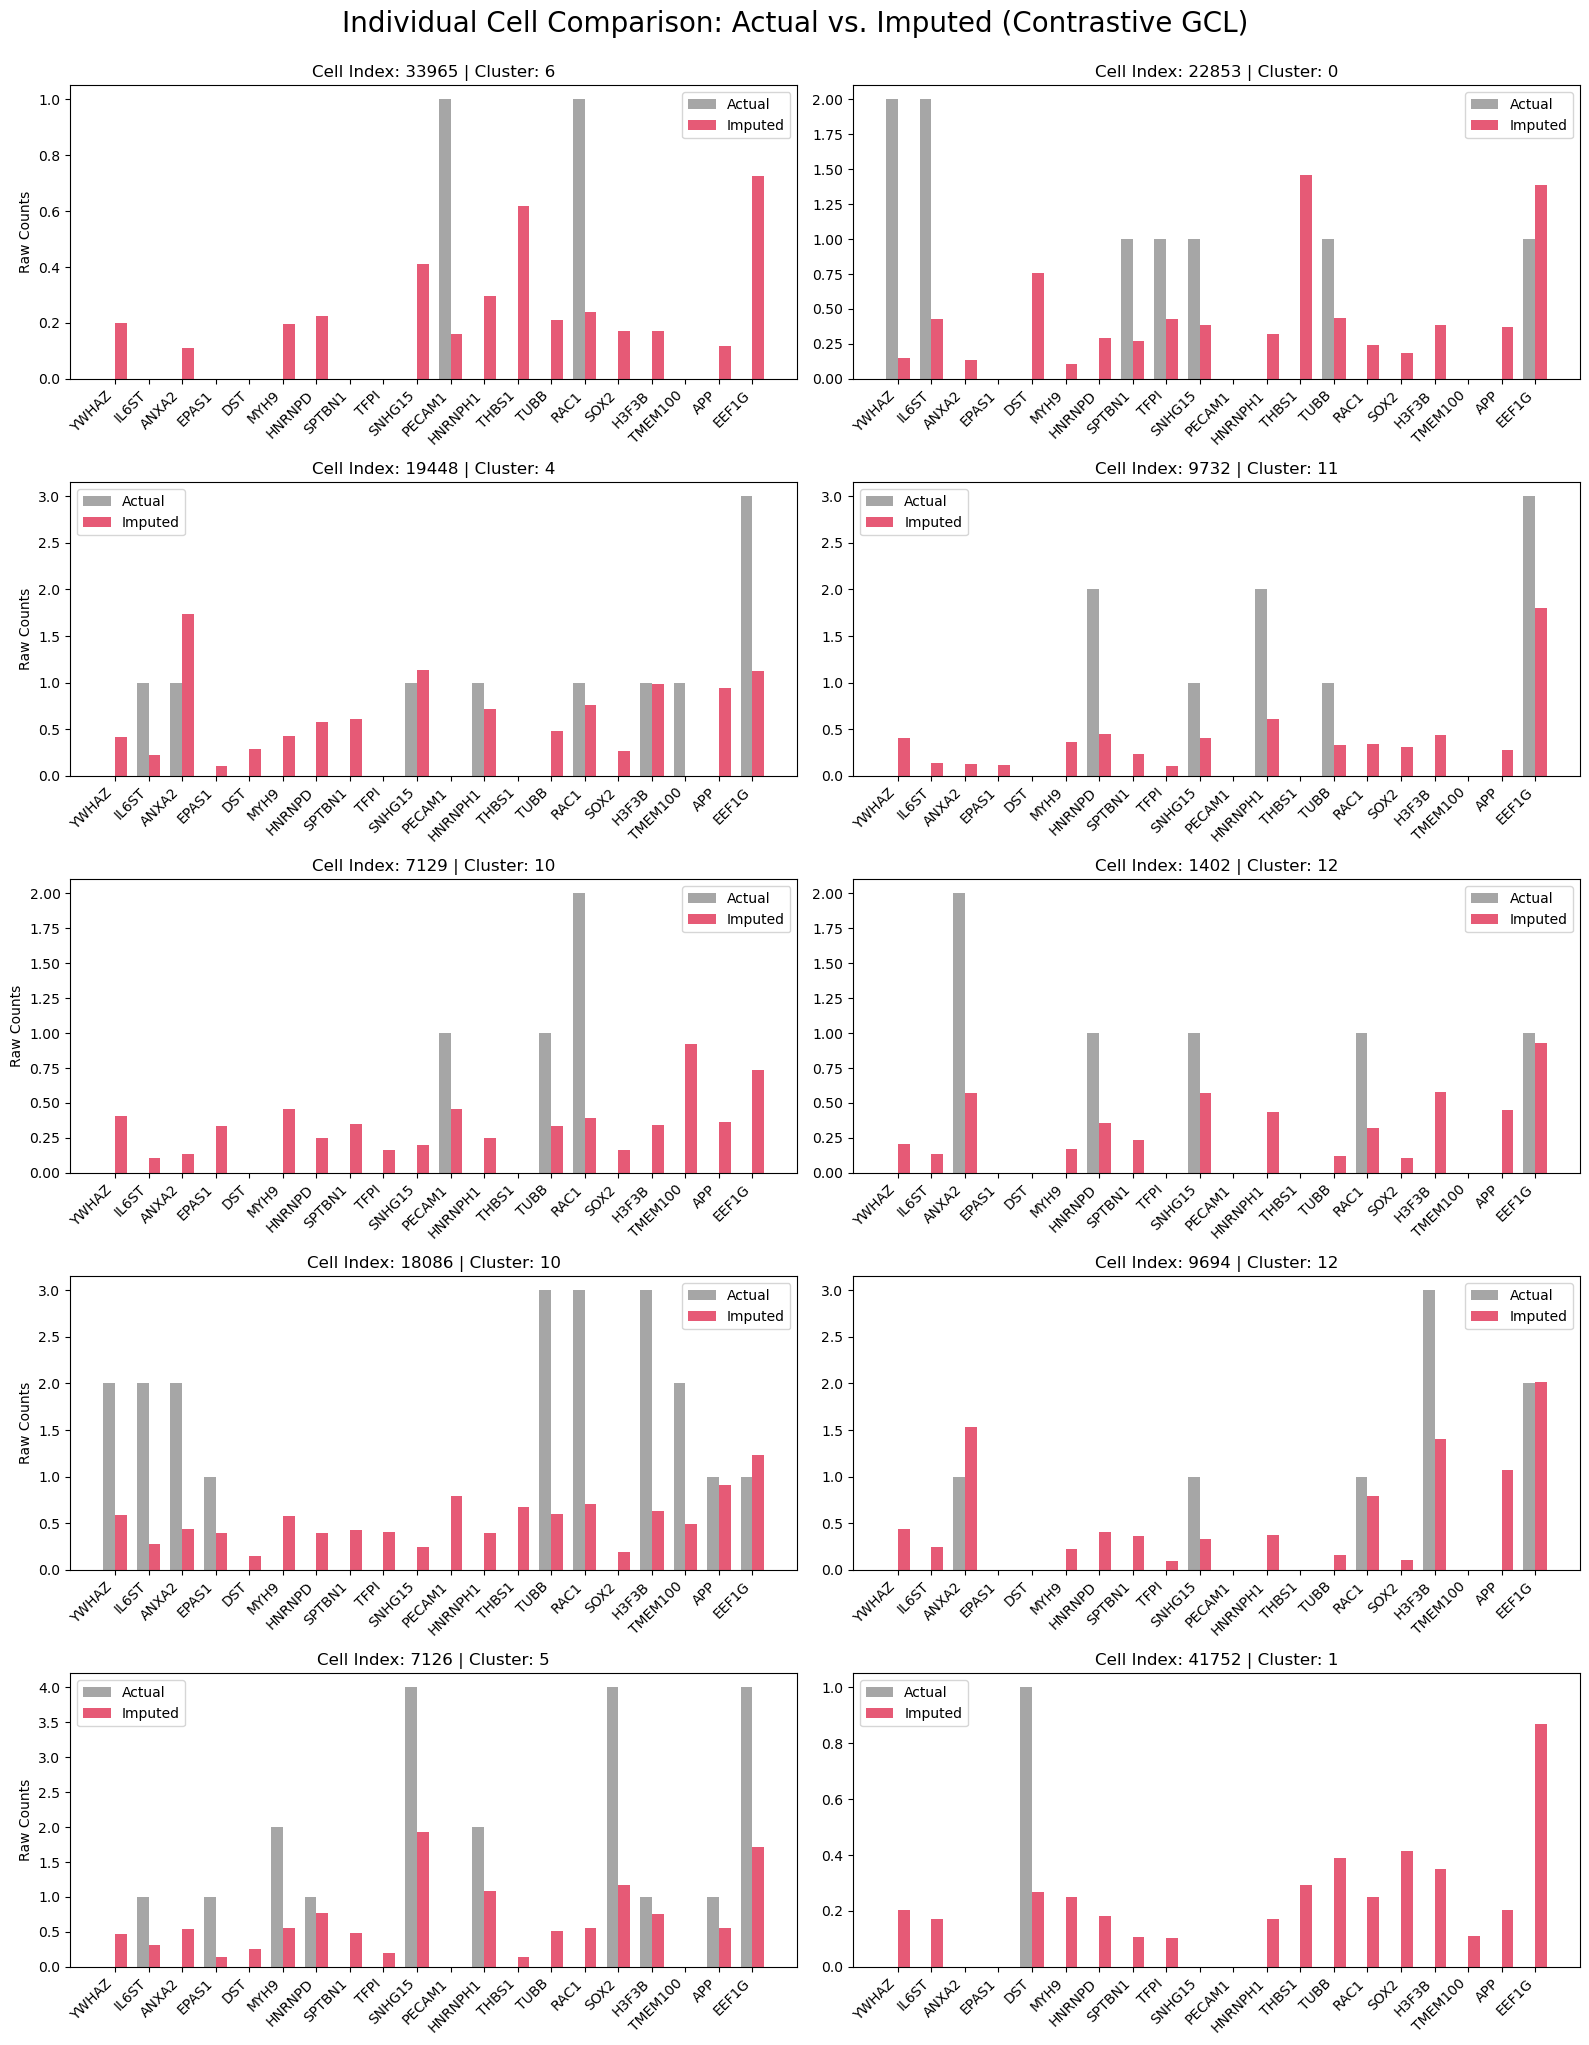

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Select 10 random cells from the evaluation matrix
np.random.seed(42) 
random_indices = np.random.choice(target_matrix.shape[0], 10, replace=False)

# 2. Identify the top 20 genes overall 
top_gene_indices = np.argsort(target_matrix.mean(axis=0))[-20:]
gene_labels = [adata_prime.var_names[i].split('-')[0] for i in top_gene_indices]

# 3. Create the Visualization
fig, axes = plt.subplots(5, 2, figsize=(16, 20))
axes = axes.flatten()

for i, cell_idx in enumerate(random_indices):
    cell_actual = target_matrix[cell_idx, top_gene_indices]
    cell_pred = pred_matrix[cell_idx, top_gene_indices]
    
    x = np.arange(len(gene_labels))
    width = 0.35
    
    axes[i].bar(x - width/2, cell_actual, width, label='Actual', color='gray', alpha=0.7)
    axes[i].bar(x + width/2, cell_pred, width, label='Imputed', color='crimson', alpha=0.7)
    
    axes[i].set_title(f"Cell Index: {cell_idx} | Cluster: {adata_v1.obs['v1_cluster_identity'].iloc[cell_idx]}")
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(gene_labels, rotation=45, ha='right')
    if i % 2 == 0: axes[i].set_ylabel("Raw Counts")
    axes[i].legend()

plt.tight_layout()
plt.suptitle("Individual Cell Comparison: Actual vs. Imputed (Contrastive GCL)", fontsize=20, y=1.02)
plt.show()

In [47]:
import torch
import numpy as np
from torch_geometric.loader import NeighborLoader

# 1. Extract the new high-resolution clusters
cluster_labels = adata_v1.obs['v1_cluster_identity'].cat.codes.values
num_unique_clusters = len(np.unique(cluster_labels))

print(f"Total Unique Leiden Clusters (Resolution 2.0): {num_unique_clusters}")

# 2. Attach the biological anchors to the PyTorch spatial graph
data.cluster = torch.tensor(cluster_labels, dtype=torch.long)

# 3. Initialize the High-Capacity Loader
print("Initializing DataLoader for wider spatial context...")
loader = NeighborLoader(
    data,
    num_neighbors=[25, 10], 
    batch_size=2048, 
    shuffle=True, 
    num_workers=0
)

print(f"New total batches per epoch: {len(loader)}")

Total Unique Leiden Clusters (Resolution 2.0): 25
Initializing DataLoader for wider spatial context...
New total batches per epoch: 49


In [48]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SparseMSELoss(nn.Module):
    def __init__(self, l1_weight=0.05):
        super(SparseMSELoss, self).__init__()
        self.mse = nn.MSELoss()
        self.l1_weight = l1_weight

    def forward(self, y_true_log, y_pred_log):
        # 1. Base shape matching (MSE)
        loss_mse = self.mse(y_pred_log, y_true_log)
        
        # 2. The Vacuum Cleaner (L1 Sparsity)
        # Penalizes the absolute magnitude of predictions, crushing the noise floor
        loss_l1 = torch.mean(torch.abs(y_pred_log))
        
        return loss_mse + (self.l1_weight * loss_l1)

In [49]:
from torch_geometric.nn import GATConv

class XenImputeDirect(nn.Module):
    def __init__(self, num_clusters, in_channels=480, hidden_channels=512, out_channels=5001, emb_dim=32, heads=4, dropout=0.2):
        super(XenImputeDirect, self).__init__()
        self.cluster_emb = nn.Embedding(num_clusters, emb_dim)
        
        # Encoder (Neighborhood)
        self.gat1 = GATConv(in_channels + emb_dim, hidden_channels // heads, heads=heads, dropout=dropout)
        self.gat2 = GATConv(hidden_channels, hidden_channels // heads, heads=heads, concat=True, dropout=dropout)
        
        # Residual (Intracellular)
        self.residual_proj = nn.Linear(in_channels, hidden_channels)

        # Decoder (Direct to Target)
        self.decoder = nn.Linear(hidden_channels, out_channels)     

    def forward(self, x, edge_index, cluster_id):
        # 1. Neighborhood Context
        emb = self.cluster_emb(cluster_id)
        g_in = torch.cat([x, emb], dim=1)
        g_out = F.elu(self.gat1(g_in, edge_index))
        g_out = F.elu(self.gat2(g_out, edge_index))
        
        # 2. Intracellular Truth (The Anchor)
        res_out = F.elu(self.residual_proj(x))
        
        # 3. FUSION with Self-Loop Domination
        # We mathematically force the network to listen to the cell itself 10x more than the neighbors
        z = g_out + (res_out * 10.0)
        
        # 4. Final Output (ReLU ensures we never predict negative transcripts)
        predicted_log_expr = F.relu(self.decoder(z))
        
        return predicted_log_expr

In [50]:
import time
import torch.optim as optim

print("--- INITIALIZING DIRECT XENIMPUTE ---")
model_direct = XenImputeDirect(
    num_clusters=num_unique_clusters, 
    in_channels=480, 
    hidden_channels=512, 
    out_channels=5001
).to(device)

# L1 weight of 0.05 is usually enough to kill the noise floor without hurting true high-expressers
criterion = SparseMSELoss(l1_weight=0.05) 
optimizer = optim.Adam(model_direct.parameters(), lr=1e-4, weight_decay=1e-4)

epochs = 100
print(f"Starting Direct Training on {test_core_name}...\n")

for epoch in range(epochs):
    model_direct.train()
    start_time = time.time()
    
    epoch_loss = 0.0
    valid_batches = 0
    
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        
        # Forward pass outputs log1p predictions directly
        pred_log = model_direct(batch.x, batch.edge_index, batch.cluster)
        
        # Convert targets to log1p space for MSE comparison
        y_true_raw = batch.y[:batch.batch_size]
        y_true_log = torch.log1p(y_true_raw)
        
        pred_log_seed = pred_log[:batch.batch_size]
        
        loss = criterion(y_true_log, pred_log_seed)
        
        if torch.isnan(loss): continue
            
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_direct.parameters(), max_norm=1.0)
        optimizer.step()
        
        epoch_loss += loss.item()
        valid_batches += 1
    
    if (epoch + 1) % 10 == 0 or epoch == 0:
        duration = time.time() - start_time
        avg_loss = epoch_loss / valid_batches
        print(f"Epoch [{epoch+1:03d}/{epochs}] | Sparse MSE Loss: {avg_loss:.4f} | {duration:.1f}s/ep")

print("\n--- TRAINING COMPLETE ---")

--- INITIALIZING DIRECT XENIMPUTE ---
Starting Direct Training on PDL095D...

Epoch [001/100] | Sparse MSE Loss: 1.8871 | 5.7s/ep
Epoch [010/100] | Sparse MSE Loss: 0.0097 | 4.9s/ep
Epoch [020/100] | Sparse MSE Loss: 0.0096 | 5.5s/ep
Epoch [030/100] | Sparse MSE Loss: 0.0095 | 5.5s/ep
Epoch [040/100] | Sparse MSE Loss: 0.0095 | 5.6s/ep
Epoch [050/100] | Sparse MSE Loss: 0.0095 | 5.7s/ep
Epoch [060/100] | Sparse MSE Loss: 0.0094 | 5.6s/ep
Epoch [070/100] | Sparse MSE Loss: 0.0094 | 5.6s/ep
Epoch [080/100] | Sparse MSE Loss: 0.0094 | 5.7s/ep
Epoch [090/100] | Sparse MSE Loss: 0.0093 | 5.6s/ep
Epoch [100/100] | Sparse MSE Loss: 0.0093 | 5.7s/ep

--- TRAINING COMPLETE ---


In [51]:
import numpy as np
from scipy.stats import pearsonr
from sklearn.metrics import r2_score

print("1. Preparing Evaluation Loader...")
eval_loader = NeighborLoader(data, num_neighbors=[25, 10], batch_size=2048, shuffle=False, num_workers=0)

model_direct.eval()
all_predictions_log = []
all_targets_log = []

print("2. Running Direct Inference...")
with torch.no_grad():
    for batch in eval_loader:
        batch = batch.to(device)
        
        # Model outputs predictions in log1p space
        pred_log = model_direct(batch.x, batch.edge_index, batch.cluster)
        
        target_raw = batch.y[:batch.batch_size]
        target_log = torch.log1p(target_raw)
        
        all_predictions_log.append(pred_log[:batch.batch_size].cpu().numpy())
        all_targets_log.append(target_log.cpu().numpy())

pred_matrix_log = np.vstack(all_predictions_log)
target_matrix_log = np.vstack(all_targets_log)

print("\n3. Calculating Direct Log1p Metrics...")

# Global Pearson
true_gene_means = target_matrix_log.mean(axis=0)
pred_gene_means = pred_matrix_log.mean(axis=0)
gene_pearson, _ = pearsonr(true_gene_means, pred_gene_means)

# Cell-wise R-squared (Calculated directly on the log output)
cell_r2_scores = r2_score(target_matrix_log.T, pred_matrix_log.T, multioutput='raw_values')
median_cell_r2 = np.median(cell_r2_scores)

print(f"Direct Global Gene Correlation (Pearson): {gene_pearson:.4f}")
print(f"Direct Median Cell-wise R-squared: {median_cell_r2:.4f}")

1. Preparing Evaluation Loader...
2. Running Direct Inference...

3. Calculating Direct Log1p Metrics...
Direct Global Gene Correlation (Pearson): 0.5228
Direct Median Cell-wise R-squared: 0.0016


In [52]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv

class XenImputeFusion(nn.Module):
    def __init__(self, num_clusters, in_channels=480, hidden_channels=512, out_channels=5001, emb_dim=32, heads=4, dropout=0.2):
        super(XenImputeFusion, self).__init__()
        self.cluster_emb = nn.Embedding(num_clusters, emb_dim)
        
        # --- THE ENCODER ---
        self.gat1 = GATConv(in_channels + emb_dim, hidden_channels // heads, heads=heads, dropout=dropout)
        self.gat2 = GATConv(hidden_channels, hidden_channels // heads, heads=heads, concat=True, dropout=dropout)
        
        # STMSGAL Fusion Dimension: 480 (Raw) + 512 (GAT1) + 512 (GAT2) = 1504
        fusion_dim = in_channels + hidden_channels + hidden_channels

        # --- THE PRIME DECODER (Imputation) ---
        self.dec_mu = nn.Linear(fusion_dim, out_channels)     
        self.dec_theta = nn.Linear(fusion_dim, out_channels)  
        self.dec_pi = nn.Linear(fusion_dim, out_channels)     

        # --- THE TANGRAM DECODER (V1 Auto-Reconstruction Anchor) ---
        self.recon_mu = nn.Linear(hidden_channels, in_channels)

    def forward(self, x, edge_index, cluster_id):
        # 1. Network Forward Pass
        emb = self.cluster_emb(cluster_id)
        g_in = torch.cat([x, emb], dim=1)
        
        g1_out = F.elu(self.gat1(g_in, edge_index))
        g2_out = F.elu(self.gat2(g1_out, edge_index))
        
        # 2. STMSGAL Multi-Scale Fusion
        # The decoder now sees the cell's raw self, its immediate neighbors, and its distant neighbors all at once
        z_combined = torch.cat([x, g1_out, g2_out], dim=1)
        
        # 3. Prime Imputation
        mu_prime = F.softplus(self.dec_mu(z_combined)) + 1e-6 
        theta_prime = F.softplus(self.dec_theta(z_combined)) + 1e-6
        pi_prime = torch.sigmoid(self.dec_pi(z_combined))
        
        # 4. Tangram Anchor Reconstruction
        mu_v1_recon = F.softplus(self.recon_mu(g2_out)) + 1e-6
        
        return mu_prime, theta_prime, pi_prime, mu_v1_recon

In [53]:
import time
import torch.optim as optim

print("--- INITIALIZING XENIMPUTE-FUSION (ZINB + Tangram Anchor) ---")
model_fusion = XenImputeFusion(
    num_clusters=num_unique_clusters, 
    in_channels=480, 
    hidden_channels=512, 
    out_channels=5001
).to(device)

zinb_criterion = ZINBLossStable()
recon_criterion = nn.MSELoss() # Tangram anchor loss
optimizer = optim.Adam(model_fusion.parameters(), lr=1e-4, weight_decay=1e-4)

epochs = 100
tangram_weight = 5.0  # Force the model to respect the 480 V1 genes
l1_mu_weight = 0.001  # Tiny gravity well to snap '0.3' predictions down to 0.0

print(f"Starting Fusion Training on {test_core_name}...\n")

for epoch in range(epochs):
    model_fusion.train()
    start_time = time.time()
    
    epoch_total = epoch_zinb = 0.0
    valid_batches = 0
    
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        
        # Forward Pass
        mu, theta, pi, recon_v1 = model_fusion(batch.x, batch.edge_index, batch.cluster)
        
        # Isolate seed cells for batch processing
        y_true_prime = batch.y[:batch.batch_size]
        x_true_v1 = batch.x[:batch.batch_size] # The raw 480 inputs
        
        p_mu = mu[:batch.batch_size]
        p_theta = theta[:batch.batch_size]
        p_pi = pi[:batch.batch_size]
        p_recon_v1 = recon_v1[:batch.batch_size]
        
        # 1. Prime Target Loss (ZINB)
        loss_zinb = zinb_criterion(y_true_prime, p_mu, p_theta, p_pi)
        
        # 2. Tangram Anchor Loss (Can the model recreate its own input?)
        loss_tangram = recon_criterion(p_recon_v1, x_true_v1)
        
        # 3. ZINB Zero-Optimization (L1 on predicted mean to kill the hum)
        loss_l1 = torch.mean(torch.abs(p_mu))
        
        # Combine
        total_loss = loss_zinb + (tangram_weight * loss_tangram) + (l1_mu_weight * loss_l1)
        
        if torch.isnan(total_loss): continue
            
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model_fusion.parameters(), max_norm=1.0)
        optimizer.step()
        
        epoch_total += total_loss.item()
        epoch_zinb += loss_zinb.item()
        valid_batches += 1
    
    if (epoch + 1) % 10 == 0 or epoch == 0:
        duration = time.time() - start_time
        avg_total = epoch_total / valid_batches
        avg_zinb = epoch_zinb / valid_batches
        print(f"Epoch [{epoch+1:03d}/{epochs}] | Total: {avg_total:.4f} | ZINB: {avg_zinb:.4f}")

print("\n--- TRAINING COMPLETE ---")

--- INITIALIZING XENIMPUTE-FUSION (ZINB + Tangram Anchor) ---
Starting Fusion Training on PDL095D...

Epoch [001/100] | Total: 9.6201 | ZINB: 0.1259
Epoch [010/100] | Total: 4.8048 | ZINB: 0.0750
Epoch [020/100] | Total: 4.2006 | ZINB: 0.0747
Epoch [030/100] | Total: 3.9390 | ZINB: 0.0745
Epoch [040/100] | Total: 3.7862 | ZINB: 0.0744
Epoch [050/100] | Total: 3.6871 | ZINB: 0.0743
Epoch [060/100] | Total: 3.5990 | ZINB: 0.0744
Epoch [070/100] | Total: 3.5439 | ZINB: 0.0744
Epoch [080/100] | Total: 3.4825 | ZINB: 0.0743
Epoch [090/100] | Total: 3.4468 | ZINB: 0.0744
Epoch [100/100] | Total: 3.4104 | ZINB: 0.0744

--- TRAINING COMPLETE ---


In [54]:
import numpy as np
from scipy.stats import pearsonr
from sklearn.metrics import r2_score

print("1. Preparing Evaluation Loader...")
eval_loader = NeighborLoader(data, num_neighbors=[25, 10], batch_size=2048, shuffle=False, num_workers=0)

model_fusion.eval()
all_predictions = []
all_targets = []

print("2. Running Fusion Inference...")
with torch.no_grad():
    for batch in eval_loader:
        batch = batch.to(device)
        
        # Unpack the 4 outputs, ignore the reconstruction for evaluation
        mu, theta, pi, _ = model_fusion(batch.x, batch.edge_index, batch.cluster)
        
        target_y = batch.y[:batch.batch_size].cpu().numpy()
        pred_mu = mu[:batch.batch_size].cpu().numpy()
        pred_pi = pi[:batch.batch_size].cpu().numpy()
        
        # Expected Value E[Y]
        expected_counts = (1.0 - pred_pi) * pred_mu
        
        # Safe Noise Gate
        expected_counts[expected_counts < 0.1] = 0.0
        
        all_predictions.append(expected_counts)
        all_targets.append(target_y)

pred_matrix = np.vstack(all_predictions)
target_matrix = np.vstack(all_targets)

print("\n3. Calculating Fusion ZINB Metrics...")
log_target_matrix = np.log1p(target_matrix)
log_pred_matrix = np.log1p(pred_matrix)

true_gene_means = log_target_matrix.mean(axis=0)
pred_gene_means = log_pred_matrix.mean(axis=0)
gene_pearson, _ = pearsonr(true_gene_means, pred_gene_means)

cell_r2_scores = r2_score(log_target_matrix.T, log_pred_matrix.T, multioutput='raw_values')
median_cell_r2 = np.median(cell_r2_scores)

print(f"Fusion Global Gene Correlation (Pearson): {gene_pearson:.4f}")
print(f"Fusion Median Cell-wise R-squared: {median_cell_r2:.4f}")

1. Preparing Evaluation Loader...
2. Running Fusion Inference...

3. Calculating Fusion ZINB Metrics...
Fusion Global Gene Correlation (Pearson): 0.9166
Fusion Median Cell-wise R-squared: 0.0417


In [55]:
import torch
from torch.utils.data import TensorDataset, DataLoader

print("1. Stripping PyTorch Geometric Graph...")
# Extract pure intracellular features and targets
x_tensor = data.x
y_tensor = data.y

# Create a standard dataset (No edges, no neighbors)
mlp_dataset = TensorDataset(x_tensor, y_tensor)

# We can use a massive batch size because there is no spatial graph memory overhead
mlp_loader = DataLoader(mlp_dataset, batch_size=4096, shuffle=True)
print(f"MLP DataLoader ready. Total batches per epoch: {len(mlp_loader)}")

1. Stripping PyTorch Geometric Graph...
MLP DataLoader ready. Total batches per epoch: 25


In [56]:
import torch.nn as nn
import torch.nn.functional as F

class XenImputeMLP(nn.Module):
    def __init__(self, in_channels=480, hidden_channels=1024, out_channels=5001, dropout=0.2):
        super(XenImputeMLP, self).__init__()
        
        # A wide, 3-layer dense network
        self.fc1 = nn.Linear(in_channels, hidden_channels)
        self.fc2 = nn.Linear(hidden_channels, hidden_channels)
        self.fc3 = nn.Linear(hidden_channels, hidden_channels)

        # ZINB Decoder
        self.dec_mu = nn.Linear(hidden_channels, out_channels)     
        self.dec_theta = nn.Linear(hidden_channels, out_channels)  
        self.dec_pi = nn.Linear(hidden_channels, out_channels)     
        
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # Pure intracellular feature extraction
        h = F.elu(self.fc1(x))
        h = self.dropout(h)
        h = F.elu(self.fc2(h))
        h = self.dropout(h)
        h = F.elu(self.fc3(h))
        
        # Prime Imputation
        mu = F.softplus(self.dec_mu(h)) + 1e-6 
        theta = F.softplus(self.dec_theta(h)) + 1e-6
        pi = torch.sigmoid(self.dec_pi(h))
        
        return mu, theta, pi

In [57]:
import time
import torch.optim as optim

print("--- INITIALIZING XENIMPUTE-MLP (Ablation Baseline) ---")
model_mlp = XenImputeMLP(
    in_channels=480, 
    hidden_channels=1024, 
    out_channels=5001
).to(device)

zinb_criterion = ZINBLossStable()
optimizer = optim.Adam(model_mlp.parameters(), lr=1e-4, weight_decay=1e-4)

epochs = 100
print("Starting Pure Intracellular Training...\n")

for epoch in range(epochs):
    model_mlp.train()
    start_time = time.time()
    
    epoch_zinb = 0.0
    valid_batches = 0
    
    # We unpack x and y directly from the standard loader
    for batch_x, batch_y in mlp_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        
        optimizer.zero_grad()
        
        mu, theta, pi = model_mlp(batch_x)
        
        loss = zinb_criterion(batch_y, mu, theta, pi)
        
        if torch.isnan(loss): continue
            
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_mlp.parameters(), max_norm=1.0)
        optimizer.step()
        
        epoch_zinb += loss.item()
        valid_batches += 1
    
    if (epoch + 1) % 10 == 0 or epoch == 0:
        duration = time.time() - start_time
        avg_zinb = epoch_zinb / valid_batches
        print(f"Epoch [{epoch+1:03d}/{epochs}] | ZINB Loss: {avg_zinb:.4f} | {duration:.1f}s/ep")

print("\n--- TRAINING COMPLETE ---")

--- INITIALIZING XENIMPUTE-MLP (Ablation Baseline) ---
Starting Pure Intracellular Training...

Epoch [001/100] | ZINB Loss: 0.1616 | 12.6s/ep
Epoch [010/100] | ZINB Loss: 0.0744 | 11.8s/ep
Epoch [020/100] | ZINB Loss: 0.0727 | 11.8s/ep
Epoch [030/100] | ZINB Loss: 0.0724 | 11.2s/ep
Epoch [040/100] | ZINB Loss: 0.0721 | 11.9s/ep
Epoch [050/100] | ZINB Loss: 0.0720 | 11.8s/ep
Epoch [060/100] | ZINB Loss: 0.0719 | 11.4s/ep
Epoch [070/100] | ZINB Loss: 0.0719 | 11.9s/ep
Epoch [080/100] | ZINB Loss: 0.0719 | 11.2s/ep
Epoch [090/100] | ZINB Loss: 0.0719 | 12.0s/ep
Epoch [100/100] | ZINB Loss: 0.0718 | 11.2s/ep

--- TRAINING COMPLETE ---


In [58]:
import numpy as np
from scipy.stats import pearsonr
from sklearn.metrics import r2_score

print("1. Preparing Standard Evaluation Loader...")
eval_loader = DataLoader(mlp_dataset, batch_size=4096, shuffle=False)

model_mlp.eval()
all_predictions = []
all_targets = []

print("2. Running MLP Inference...")
with torch.no_grad():
    for batch_x, batch_y in eval_loader:
        batch_x = batch_x.to(device)
        
        mu, theta, pi = model_mlp(batch_x)
        
        target_y = batch_y.cpu().numpy()
        pred_mu = mu.cpu().numpy()
        pred_pi = pi.cpu().numpy()
        
        expected_counts = (1.0 - pred_pi) * pred_mu
        expected_counts[expected_counts < 0.1] = 0.0
        
        all_predictions.append(expected_counts)
        all_targets.append(target_y)

pred_matrix = np.vstack(all_predictions)
target_matrix = np.vstack(all_targets)

print("\n3. Calculating MLP ZINB Metrics...")
log_target_matrix = np.log1p(target_matrix)
log_pred_matrix = np.log1p(pred_matrix)

true_gene_means = log_target_matrix.mean(axis=0)
pred_gene_means = log_pred_matrix.mean(axis=0)
gene_pearson, _ = pearsonr(true_gene_means, pred_gene_means)

cell_r2_scores = r2_score(log_target_matrix.T, log_pred_matrix.T, multioutput='raw_values')
median_cell_r2 = np.median(cell_r2_scores)

print(f"MLP Baseline Global Gene Correlation (Pearson): {gene_pearson:.4f}")
print(f"MLP Baseline Median Cell-wise R-squared: {median_cell_r2:.4f}")

1. Preparing Standard Evaluation Loader...
2. Running MLP Inference...

3. Calculating MLP ZINB Metrics...
MLP Baseline Global Gene Correlation (Pearson): 0.9322
MLP Baseline Median Cell-wise R-squared: 0.0265


In [59]:
import torch
import torch.nn as nn

class WeightedZINBLoss(nn.Module):
    def __init__(self, eps=1e-6):
        super(WeightedZINBLoss, self).__init__()
        self.eps = eps

    def forward(self, y_true, mu, theta, pi, gene_weights):
        pi = torch.clamp(pi, min=self.eps, max=1.0 - self.eps)
        t1 = torch.lgamma(theta + y_true) - torch.lgamma(theta) - torch.lgamma(y_true + 1.0)
        t2 = theta * (torch.log(theta + self.eps) - torch.log(theta + mu + self.eps))
        t3 = y_true * (torch.log(mu + self.eps) - torch.log(theta + mu + self.eps))
        nb_log_pdf = t1 + t2 + t3
        
        zero_mask = (y_true < self.eps).float()
        zero_loss = torch.log(pi + (1 - pi) * torch.exp(nb_log_pdf) + self.eps)
        nonzero_loss = torch.log(1 - pi) + nb_log_pdf
        
        # Calculate the raw loss per cell, per gene -> Shape: (Batch_Size, 5001)
        raw_loss = -(zero_mask * zero_loss + (1 - zero_mask) * nonzero_loss)
        
        # Apply the Modulators
        # Broadcasts the (5001) weight vector across the batch dimension
        weighted_loss = raw_loss * gene_weights.unsqueeze(0)
        
        return torch.mean(weighted_loss)

In [60]:
import torch.nn.functional as F
from torch_geometric.nn import GATConv

class XenImputeAdaptive(nn.Module):
    def __init__(self, num_clusters, in_channels=480, hidden_channels=512, out_channels=5001, emb_dim=32, heads=4, dropout=0.2):
        super(XenImputeAdaptive, self).__init__()
        self.cluster_emb = nn.Embedding(num_clusters, emb_dim)
        
        # --- THE MODULATOR ---
        # A learnable parameter for every single gene
        self.raw_gene_weights = nn.Parameter(torch.ones(out_channels))
        
        # Encoder (Spatial + Intracellular)
        self.gat1 = GATConv(in_channels + emb_dim, hidden_channels // heads, heads=heads, dropout=dropout)
        self.gat2 = GATConv(hidden_channels, hidden_channels // heads, heads=heads, concat=True, dropout=dropout)
        self.residual_proj = nn.Linear(in_channels, hidden_channels)

        # Decoder
        self.dec_mu = nn.Linear(hidden_channels, out_channels)     
        self.dec_theta = nn.Linear(hidden_channels, out_channels)  
        self.dec_pi = nn.Linear(hidden_channels, out_channels)     

    def get_gene_weights(self):
        # The Focus Budget: Softmax ensures they sum to 1. 
        # Multiply by out_channels so the overall average weight remains exactly 1.0
        return F.softmax(self.raw_gene_weights, dim=0) * self.raw_gene_weights.shape[0]

    def forward(self, x, edge_index, cluster_id):
        emb = self.cluster_emb(cluster_id)
        g_in = torch.cat([x, emb], dim=1)
        
        g_out = F.elu(self.gat1(g_in, edge_index))
        g_out = F.elu(self.gat2(g_out, edge_index))
        res_out = F.elu(self.residual_proj(x))
        
        z = g_out + res_out 
        
        mu = F.softplus(self.dec_mu(z)) + 1e-6 
        theta = F.softplus(self.dec_theta(z)) + 1e-6
        pi = torch.sigmoid(self.dec_pi(z))
        
        return mu, theta, pi

In [61]:
import time
import torch.optim as optim

print("--- INITIALIZING XENIMPUTE-ADAPTIVE ---")
model_adaptive = XenImputeAdaptive(
    num_clusters=num_unique_clusters, 
    in_channels=480, 
    hidden_channels=512, 
    out_channels=5001
).to(device)

weighted_criterion = WeightedZINBLoss()
optimizer = optim.Adam(model_adaptive.parameters(), lr=1e-4, weight_decay=1e-4)

epochs = 100
print(f"Starting Adaptive Training on {test_core_name}...\n")

for epoch in range(epochs):
    model_adaptive.train()
    start_time = time.time()
    
    epoch_loss = 0.0
    valid_batches = 0
    
    for batch in loader: # Using the PyTorch Geometric loader
        batch = batch.to(device)
        optimizer.zero_grad()
        
        mu, theta, pi = model_adaptive(batch.x, batch.edge_index, batch.cluster)
        
        y_true = batch.y[:batch.batch_size]
        p_mu = mu[:batch.batch_size]
        p_theta = theta[:batch.batch_size]
        p_pi = pi[:batch.batch_size]
        
        # Dynamically fetch the current "Focus Budget"
        current_weights = model_adaptive.get_gene_weights()
        
        loss = weighted_criterion(y_true, p_mu, p_theta, p_pi, current_weights)
        
        if torch.isnan(loss): continue
            
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_adaptive.parameters(), max_norm=1.0)
        optimizer.step()
        
        epoch_loss += loss.item()
        valid_batches += 1
    
    if (epoch + 1) % 10 == 0 or epoch == 0:
        duration = time.time() - start_time
        avg_loss = epoch_loss / valid_batches
        print(f"Epoch [{epoch+1:03d}/{epochs}] | Weighted ZINB Loss: {avg_loss:.4f} | {duration:.1f}s/ep")

print("\n--- TRAINING COMPLETE ---")

--- INITIALIZING XENIMPUTE-ADAPTIVE ---
Starting Adaptive Training on PDL095D...

Epoch [001/100] | Weighted ZINB Loss: 0.1319 | 8.8s/ep
Epoch [010/100] | Weighted ZINB Loss: 0.0743 | 8.7s/ep
Epoch [020/100] | Weighted ZINB Loss: 0.0731 | 8.8s/ep
Epoch [030/100] | Weighted ZINB Loss: 0.0728 | 8.3s/ep
Epoch [040/100] | Weighted ZINB Loss: 0.0726 | 9.0s/ep
Epoch [050/100] | Weighted ZINB Loss: 0.0725 | 9.0s/ep
Epoch [060/100] | Weighted ZINB Loss: 0.0724 | 9.0s/ep
Epoch [070/100] | Weighted ZINB Loss: 0.0724 | 9.0s/ep
Epoch [080/100] | Weighted ZINB Loss: 0.0723 | 8.4s/ep
Epoch [090/100] | Weighted ZINB Loss: 0.0722 | 9.0s/ep
Epoch [100/100] | Weighted ZINB Loss: 0.0721 | 9.0s/ep

--- TRAINING COMPLETE ---


In [62]:
import numpy as np
from scipy.stats import pearsonr
from sklearn.metrics import r2_score

print("1. Preparing Spatial Evaluation Loader...")
eval_loader = NeighborLoader(data, num_neighbors=[25, 10], batch_size=2048, shuffle=False, num_workers=0)

model_adaptive.eval()
all_predictions = []
all_targets = []

print("2. Running Adaptive Inference...")
with torch.no_grad():
    for batch in eval_loader:
        batch = batch.to(device)
        
        mu, theta, pi = model_adaptive(batch.x, batch.edge_index, batch.cluster)
        
        target_y = batch.y[:batch.batch_size].cpu().numpy()
        pred_mu = mu[:batch.batch_size].cpu().numpy()
        pred_pi = pi[:batch.batch_size].cpu().numpy()
        
        expected_counts = (1.0 - pred_pi) * pred_mu
        expected_counts[expected_counts < 0.1] = 0.0
        
        all_predictions.append(expected_counts)
        all_targets.append(target_y)

pred_matrix = np.vstack(all_predictions)
target_matrix = np.vstack(all_targets)

print("\n3. Calculating Adaptive ZINB Metrics...")
log_target_matrix = np.log1p(target_matrix)
log_pred_matrix = np.log1p(pred_matrix)

true_gene_means = log_target_matrix.mean(axis=0)
pred_gene_means = log_pred_matrix.mean(axis=0)
gene_pearson, _ = pearsonr(true_gene_means, pred_gene_means)

cell_r2_scores = r2_score(log_target_matrix.T, log_pred_matrix.T, multioutput='raw_values')
median_cell_r2 = np.median(cell_r2_scores)

print(f"Adaptive Global Gene Correlation (Pearson): {gene_pearson:.4f}")
print(f"Adaptive Median Cell-wise R-squared: {median_cell_r2:.4f}")

1. Preparing Spatial Evaluation Loader...
2. Running Adaptive Inference...

3. Calculating Adaptive ZINB Metrics...
Adaptive Global Gene Correlation (Pearson): 0.9159
Adaptive Median Cell-wise R-squared: 0.0343


In [63]:
import torch
import torch.nn as nn

class HurdleNBLoss(nn.Module):
    def __init__(self, eps=1e-6, gate_weight=1.0):
        super(HurdleNBLoss, self).__init__()
        self.eps = eps
        self.gate_weight = gate_weight
        self.bce = nn.BCELoss()

    def forward(self, y_true, mu, theta, pi):
        # 1. The Gatekeeper (Binary Classification)
        # 1.0 if true count is zero, 0.0 if expressed
        is_zero = (y_true < self.eps).float() 
        pi = torch.clamp(pi, min=self.eps, max=1.0 - self.eps)
        
        # Force pi to strictly learn the sparsity map
        loss_gate = self.bce(pi, is_zero)

        # 2. The Counter (Negative Binomial)
        # Create a mask for genes that actually have transcripts
        mask_positive = (1.0 - is_zero)
        
        # Standard NB Log Likelihood
        t1 = torch.lgamma(theta + y_true) - torch.lgamma(theta) - torch.lgamma(y_true + 1.0)
        t2 = theta * (torch.log(theta + self.eps) - torch.log(theta + mu + self.eps))
        t3 = y_true * (torch.log(mu + self.eps) - torch.log(theta + mu + self.eps))
        nb_log_pdf = t1 + t2 + t3
        
        # Invert to positive loss, apply mask, and calculate mean OVER POSITIVE INSTANCES ONLY
        # This forces the network to focus all count-learning power on the high expressers
        loss_nb = - (nb_log_pdf * mask_positive).sum() / (mask_positive.sum() + self.eps)
        
        return (self.gate_weight * loss_gate) + loss_nb

In [64]:
# Re-initializing the standard 2-layer GAT model
print("--- INITIALIZING XENIMPUTE-HURDLE ---")
model_hurdle = XenImputeResNet(
    num_clusters=num_unique_clusters, 
    in_channels=480, 
    hidden_channels=512, 
    out_channels=5001
).to(device)

# We initialize the new strict Hurdle Loss
hurdle_criterion = HurdleNBLoss(gate_weight=1.0)
optimizer = optim.Adam(model_hurdle.parameters(), lr=1e-4, weight_decay=1e-4)

--- INITIALIZING XENIMPUTE-HURDLE ---


In [65]:
import time

epochs = 100
print(f"Starting Hurdle NB Training on {test_core_name}...\n")

for epoch in range(epochs):
    model_hurdle.train()
    start_time = time.time()
    
    epoch_total = epoch_gate = epoch_nb = 0.0
    valid_batches = 0
    
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        
        mu, theta, pi = model_hurdle(batch.x, batch.edge_index, batch.cluster)
        
        y_true = batch.y[:batch.batch_size]
        p_mu = mu[:batch.batch_size]
        p_theta = theta[:batch.batch_size]
        p_pi = pi[:batch.batch_size]
        
        # The loss automatically handles the routing
        loss = hurdle_criterion(y_true, p_mu, p_theta, p_pi)
        
        if torch.isnan(loss): continue
            
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_hurdle.parameters(), max_norm=1.0)
        optimizer.step()
        
        epoch_total += loss.item()
        valid_batches += 1
    
    if (epoch + 1) % 10 == 0 or epoch == 0:
        duration = time.time() - start_time
        avg_total = epoch_total / valid_batches
        print(f"Epoch [{epoch+1:03d}/{epochs}] | Hurdle Total Loss: {avg_total:.4f} | {duration:.1f}s/ep")

print("\n--- TRAINING COMPLETE ---")

Starting Hurdle NB Training on PDL095D...

Epoch [001/100] | Hurdle Total Loss: 1.8526 | 8.3s/ep
Epoch [010/100] | Hurdle Total Loss: 1.2000 | 8.4s/ep
Epoch [020/100] | Hurdle Total Loss: 1.1771 | 8.4s/ep
Epoch [030/100] | Hurdle Total Loss: 1.1709 | 8.4s/ep
Epoch [040/100] | Hurdle Total Loss: 1.1682 | 7.8s/ep
Epoch [050/100] | Hurdle Total Loss: 1.1670 | 8.5s/ep
Epoch [060/100] | Hurdle Total Loss: 1.1660 | 8.4s/ep
Epoch [070/100] | Hurdle Total Loss: 1.1655 | 8.5s/ep
Epoch [080/100] | Hurdle Total Loss: 1.1651 | 8.4s/ep
Epoch [090/100] | Hurdle Total Loss: 1.1647 | 7.7s/ep
Epoch [100/100] | Hurdle Total Loss: 1.1644 | 8.4s/ep

--- TRAINING COMPLETE ---


In [66]:
import numpy as np
from scipy.stats import pearsonr
from sklearn.metrics import r2_score

print("1. Preparing Spatial Evaluation Loader...")
eval_loader = NeighborLoader(data, num_neighbors=[25, 10], batch_size=2048, shuffle=False, num_workers=0)

model_hurdle.eval()
all_predictions = []
all_targets = []

print("2. Running Hurdle Inference...")
with torch.no_grad():
    for batch in eval_loader:
        batch = batch.to(device)
        
        mu, theta, pi = model_hurdle(batch.x, batch.edge_index, batch.cluster)
        
        target_y = batch.y[:batch.batch_size].cpu().numpy()
        pred_mu = mu[:batch.batch_size].cpu().numpy()
        pred_pi = pi[:batch.batch_size].cpu().numpy()
        
        # The Hurdle expected value remains the same: (1 - pi) * mu
        expected_counts = (1.0 - pred_pi) * pred_mu
        
        # Safe noise gate
        expected_counts[expected_counts < 0.1] = 0.0
        
        all_predictions.append(expected_counts)
        all_targets.append(target_y)

pred_matrix = np.vstack(all_predictions)
target_matrix = np.vstack(all_targets)

print("\n3. Calculating Hurdle Metrics...")
log_target_matrix = np.log1p(target_matrix)
log_pred_matrix = np.log1p(pred_matrix)

true_gene_means = log_target_matrix.mean(axis=0)
pred_gene_means = log_pred_matrix.mean(axis=0)
gene_pearson, _ = pearsonr(true_gene_means, pred_gene_means)

cell_r2_scores = r2_score(log_target_matrix.T, log_pred_matrix.T, multioutput='raw_values')
median_cell_r2 = np.median(cell_r2_scores)

print(f"Hurdle Global Gene Correlation (Pearson): {gene_pearson:.4f}")
print(f"Hurdle Median Cell-wise R-squared: {median_cell_r2:.4f}")

1. Preparing Spatial Evaluation Loader...
2. Running Hurdle Inference...

3. Calculating Hurdle Metrics...
Hurdle Global Gene Correlation (Pearson): 0.8937
Hurdle Median Cell-wise R-squared: 0.0366


In [67]:
import torch
from torch_geometric.loader import NeighborLoader

print("1. Extracting original spatial edges...")
row, col = data.edge_index

print(f"Original Edge Count: {data.edge_index.shape[1]}")

# 2. The Biological Firewall
# Create a boolean mask: True ONLY if the source cell and target cell belong to the exact same Leiden cluster
homophilic_mask = data.cluster[row] == data.cluster[col]

# 3. Apply the mask to create the pruned graph
clean_edge_index = data.edge_index[:, homophilic_mask]
data.edge_index = clean_edge_index

print(f"Pruned Edge Count (Pure Cell-Type Graph): {data.edge_index.shape[1]}")

# 4. Re-Initialize the Loader with the clean graph
print("\nInitializing Homophilic DataLoader...")
loader = NeighborLoader(
    data,
    num_neighbors=[25, 10], 
    batch_size=2048, 
    shuffle=True, 
    num_workers=0
)
print(f"New total batches per epoch: {len(loader)}")

1. Extracting original spatial edges...
Original Edge Count: 189082
Pruned Edge Count (Pure Cell-Type Graph): 163478

Initializing Homophilic DataLoader...
New total batches per epoch: 49


In [68]:
# Re-initializing the standard 2-layer GAT model
print("--- INITIALIZING XENIMPUTE-HURDLE ---")
model_hurdle = XenImputeResNet(
    num_clusters=num_unique_clusters, 
    in_channels=480, 
    hidden_channels=512, 
    out_channels=5001
).to(device)

# We initialize the new strict Hurdle Loss
hurdle_criterion = HurdleNBLoss(gate_weight=1.0)
optimizer = optim.Adam(model_hurdle.parameters(), lr=1e-4, weight_decay=1e-4)

--- INITIALIZING XENIMPUTE-HURDLE ---


In [69]:
import time

epochs = 100
print(f"Starting Hurdle NB Training on {test_core_name}...\n")

for epoch in range(epochs):
    model_hurdle.train()
    start_time = time.time()
    
    epoch_total = epoch_gate = epoch_nb = 0.0
    valid_batches = 0
    
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        
        mu, theta, pi = model_hurdle(batch.x, batch.edge_index, batch.cluster)
        
        y_true = batch.y[:batch.batch_size]
        p_mu = mu[:batch.batch_size]
        p_theta = theta[:batch.batch_size]
        p_pi = pi[:batch.batch_size]
        
        # The loss automatically handles the routing
        loss = hurdle_criterion(y_true, p_mu, p_theta, p_pi)
        
        if torch.isnan(loss): continue
            
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_hurdle.parameters(), max_norm=1.0)
        optimizer.step()
        
        epoch_total += loss.item()
        valid_batches += 1
    
    if (epoch + 1) % 10 == 0 or epoch == 0:
        duration = time.time() - start_time
        avg_total = epoch_total / valid_batches
        print(f"Epoch [{epoch+1:03d}/{epochs}] | Hurdle Total Loss: {avg_total:.4f} | {duration:.1f}s/ep")

print("\n--- TRAINING COMPLETE ---")

Starting Hurdle NB Training on PDL095D...

Epoch [001/100] | Hurdle Total Loss: 1.8719 | 7.3s/ep
Epoch [010/100] | Hurdle Total Loss: 1.1998 | 7.2s/ep
Epoch [020/100] | Hurdle Total Loss: 1.1771 | 7.3s/ep
Epoch [030/100] | Hurdle Total Loss: 1.1709 | 7.3s/ep
Epoch [040/100] | Hurdle Total Loss: 1.1683 | 7.4s/ep
Epoch [050/100] | Hurdle Total Loss: 1.1668 | 7.7s/ep
Epoch [060/100] | Hurdle Total Loss: 1.1660 | 6.8s/ep
Epoch [070/100] | Hurdle Total Loss: 1.1654 | 7.5s/ep
Epoch [080/100] | Hurdle Total Loss: 1.1650 | 7.5s/ep
Epoch [090/100] | Hurdle Total Loss: 1.1647 | 6.7s/ep
Epoch [100/100] | Hurdle Total Loss: 1.1643 | 7.4s/ep

--- TRAINING COMPLETE ---


In [70]:
import numpy as np
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import r2_score

print("1. Preparing Spatial Evaluation Loader...")
eval_loader = NeighborLoader(data, num_neighbors=[25, 10], batch_size=2048, shuffle=False, num_workers=0)

model_hurdle.eval()
all_predictions = []
all_targets = []
all_clusters = []

print("2. Running Homophilic Inference...")
with torch.no_grad():
    for batch in eval_loader:
        batch = batch.to(device)
        
        mu, theta, pi = model_hurdle(batch.x, batch.edge_index, batch.cluster)
        
        target_y = batch.y[:batch.batch_size].cpu().numpy()
        pred_mu = mu[:batch.batch_size].cpu().numpy()
        pred_pi = pi[:batch.batch_size].cpu().numpy()
        clusters = batch.cluster[:batch.batch_size].cpu().numpy()
        
        expected_counts = (1.0 - pred_pi) * pred_mu
        expected_counts[expected_counts < 0.1] = 0.0
        
        all_predictions.append(expected_counts)
        all_targets.append(target_y)
        all_clusters.append(clusters)

pred_matrix = np.vstack(all_predictions)
target_matrix = np.vstack(all_targets)
cluster_array = np.concatenate(all_clusters)

print("\n3. Calculating Multi-Tiered Metrics (Log1p Space)...")
log_target_matrix = np.log1p(target_matrix)
log_pred_matrix = np.log1p(pred_matrix)

# --- TIER 1: Single-Cell Global Baseline ---
true_gene_means = log_target_matrix.mean(axis=0)
pred_gene_means = log_pred_matrix.mean(axis=0)
sc_pearson, _ = pearsonr(true_gene_means, pred_gene_means)
sc_r2 = np.median(r2_score(log_target_matrix.T, log_pred_matrix.T, multioutput='raw_values'))

print(f"Tier 1 -> Single-Cell Global Pearson: {sc_pearson:.4f}")
print(f"Tier 1 -> Single-Cell Median R-squared: {sc_r2:.4f}\n")

# --- TIER 2 & 3: Pseudo-Bulk Identity & DEG Rank Tracking ---
pb_pearsons = []
pb_spearmans = []
unique_clusters = np.unique(cluster_array)

for c in unique_clusters:
    idx = np.where(cluster_array == c)[0]
    if len(idx) < 10: continue # Skip ultra-rare clusters for stability
    
    # Calculate the average expression profile for this specific cell type
    true_pb = log_target_matrix[idx].mean(axis=0)
    pred_pb = log_pred_matrix[idx].mean(axis=0)
    
    # Pearson: Do the relative magnitudes match?
    p_corr, _ = pearsonr(true_pb, pred_pb)
    pb_pearsons.append(p_corr)
    
    # Spearman Rank: Is the #1 highest expressed gene actually ranked #1? 
    s_corr, _ = spearmanr(true_pb, pred_pb)
    pb_spearmans.append(s_corr)

median_pb_pearson = np.median(pb_pearsons)
median_pb_spearman = np.median(pb_spearmans)

print(f"Tier 2 -> Pseudo-Bulk Cluster Correlation (Pearson): {median_pb_pearson:.4f}")
print(f"Tier 3 -> Cell-Type DEG Rank Tracking (Spearman): {median_pb_spearman:.4f}")

1. Preparing Spatial Evaluation Loader...
2. Running Homophilic Inference...

3. Calculating Multi-Tiered Metrics (Log1p Space)...
Tier 1 -> Single-Cell Global Pearson: 0.8943
Tier 1 -> Single-Cell Median R-squared: 0.0369

Tier 2 -> Pseudo-Bulk Cluster Correlation (Pearson): 0.8632
Tier 3 -> Cell-Type DEG Rank Tracking (Spearman): 0.7286


In [74]:
import torch
import torch.nn as nn

class HurdleNBLoss(nn.Module):
    def __init__(self, eps=1e-6, gate_weight=1.0):
        super(HurdleNBLoss, self).__init__()
        self.eps = eps
        self.gate_weight = gate_weight
        self.bce = nn.BCELoss()

    def forward(self, y_true, mu, theta, pi):
        # 1. The Gatekeeper: Is this gene expressed?
        is_zero = (y_true < self.eps).float() 
        pi = torch.clamp(pi, min=self.eps, max=1.0 - self.eps)
        
        loss_gate = self.bce(pi, is_zero)

        # 2. The Counter: Apply Negative Binomial ONLY to expressed genes
        mask_positive = (1.0 - is_zero)
        
        t1 = torch.lgamma(theta + y_true) - torch.lgamma(theta) - torch.lgamma(y_true + 1.0)
        t2 = theta * (torch.log(theta + self.eps) - torch.log(theta + mu + self.eps))
        t3 = y_true * (torch.log(mu + self.eps) - torch.log(theta + mu + self.eps))
        nb_log_pdf = t1 + t2 + t3
        
        loss_nb = - (nb_log_pdf * mask_positive).sum() / (mask_positive.sum() + self.eps)
        
        return (self.gate_weight * loss_gate) + loss_nb

In [75]:
import torch.nn.functional as F
from torch_geometric.nn import GATConv

class XenImputeMoE(nn.Module):
    def __init__(self, num_clusters, in_channels=480, hidden_channels=512, out_channels=5001, heads=4, dropout=0.2):
        super(XenImputeMoE, self).__init__()
        
        # 1. TRAIN BY CLUSTER: The "Experts"
        self.cluster_experts = nn.ModuleList([
            nn.Linear(in_channels, hidden_channels) for _ in range(num_clusters)
        ])
        
        # 2. BRING IT TOGETHER: The Global Spatial Encoder
        self.global_gat1 = GATConv(hidden_channels, hidden_channels // heads, heads=heads, dropout=dropout)
        self.global_gat2 = GATConv(hidden_channels, hidden_channels // heads, heads=heads, concat=True, dropout=dropout)
        
        # 3. DECODER: The Hurdle Output Heads
        self.dec_mu = nn.Linear(hidden_channels, out_channels)     
        self.dec_theta = nn.Linear(hidden_channels, out_channels)  
        self.dec_pi = nn.Linear(hidden_channels, out_channels)     

    def forward(self, x, edge_index, cluster_id):
        batch_size = x.size(0)
        
        # Empty tensor to hold specialized outputs
        expert_outputs = torch.zeros((batch_size, self.global_gat1.in_channels), device=x.device)
        
        # --- THE ROUTER ---
        unique_clusters = torch.unique(cluster_id)
        for c in unique_clusters:
            mask = (cluster_id == c)
            # Route cells only through their specific expert
            expert_outputs[mask] = F.elu(self.cluster_experts[c](x[mask]))
            
        # --- THE GLOBAL GRAPH ---
        g_out = F.elu(self.global_gat1(expert_outputs, edge_index))
        g_out = F.elu(self.global_gat2(g_out, edge_index))
        
        # --- DECODE ---
        mu = F.softplus(self.dec_mu(g_out)) + 1e-6 
        theta = F.softplus(self.dec_theta(g_out)) + 1e-6
        pi = torch.sigmoid(self.dec_pi(g_out))
        
        return mu, theta, pi

In [76]:
import time
import torch.optim as optim

print("--- INITIALIZING XENIMPUTE-MoE (Expert Routing + Hurdle Loss) ---")
model_moe = XenImputeMoE(
    num_clusters=num_unique_clusters, 
    in_channels=480, 
    hidden_channels=512, 
    out_channels=5001
).to(device)

hurdle_criterion = HurdleNBLoss(gate_weight=1.0)
optimizer = optim.Adam(model_moe.parameters(), lr=1e-4, weight_decay=1e-4)

epochs = 100
print(f"Starting MoE Training on {test_core_name}...\n")

for epoch in range(epochs):
    model_moe.train()
    start_time = time.time()
    
    epoch_loss = 0.0
    valid_batches = 0
    
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        
        mu, theta, pi = model_moe(batch.x, batch.edge_index, batch.cluster)
        
        y_true = batch.y[:batch.batch_size]
        p_mu = mu[:batch.batch_size]
        p_theta = theta[:batch.batch_size]
        p_pi = pi[:batch.batch_size]
        
        loss = hurdle_criterion(y_true, p_mu, p_theta, p_pi)
        
        if torch.isnan(loss): continue
            
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_moe.parameters(), max_norm=1.0)
        optimizer.step()
        
        epoch_loss += loss.item()
        valid_batches += 1
    
    if (epoch + 1) % 10 == 0 or epoch == 0:
        duration = time.time() - start_time
        avg_loss = epoch_loss / valid_batches
        print(f"Epoch [{epoch+1:03d}/{epochs}] | MoE Hurdle Loss: {avg_loss:.4f} | {duration:.1f}s/ep")

print("\n--- TRAINING COMPLETE ---")

--- INITIALIZING XENIMPUTE-MoE (Expert Routing + Hurdle Loss) ---
Starting MoE Training on PDL095D...

Epoch [001/100] | MoE Hurdle Loss: 1.8831 | 7.7s/ep
Epoch [010/100] | MoE Hurdle Loss: 1.1983 | 8.1s/ep
Epoch [020/100] | MoE Hurdle Loss: 1.1886 | 7.7s/ep
Epoch [030/100] | MoE Hurdle Loss: 1.1847 | 8.3s/ep
Epoch [040/100] | MoE Hurdle Loss: 1.1825 | 7.7s/ep
Epoch [050/100] | MoE Hurdle Loss: 1.1814 | 8.3s/ep
Epoch [060/100] | MoE Hurdle Loss: 1.1798 | 8.3s/ep
Epoch [070/100] | MoE Hurdle Loss: 1.1790 | 8.3s/ep
Epoch [080/100] | MoE Hurdle Loss: 1.1781 | 7.6s/ep
Epoch [090/100] | MoE Hurdle Loss: 1.1775 | 8.4s/ep
Epoch [100/100] | MoE Hurdle Loss: 1.1768 | 8.3s/ep

--- TRAINING COMPLETE ---


In [77]:
import numpy as np
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import r2_score

print("1. Preparing Spatial Evaluation Loader...")
eval_loader = NeighborLoader(data, num_neighbors=[25, 10], batch_size=2048, shuffle=False, num_workers=0)

model_moe.eval()
all_predictions = []
all_targets = []
all_clusters = []

print("2. Running MoE Inference...")
with torch.no_grad():
    for batch in eval_loader:
        batch = batch.to(device)
        
        mu, theta, pi = model_moe(batch.x, batch.edge_index, batch.cluster)
        
        target_y = batch.y[:batch.batch_size].cpu().numpy()
        pred_mu = mu[:batch.batch_size].cpu().numpy()
        pred_pi = pi[:batch.batch_size].cpu().numpy()
        clusters = batch.cluster[:batch.batch_size].cpu().numpy()
        
        expected_counts = (1.0 - pred_pi) * pred_mu
        expected_counts[expected_counts < 0.1] = 0.0
        
        all_predictions.append(expected_counts)
        all_targets.append(target_y)
        all_clusters.append(clusters)

pred_matrix = np.vstack(all_predictions)
target_matrix = np.vstack(all_targets)
cluster_array = np.concatenate(all_clusters)

print("\n3. Calculating Multi-Tiered Metrics (Log1p Space)...")
log_target_matrix = np.log1p(target_matrix)
log_pred_matrix = np.log1p(pred_matrix)

# --- TIER 1: Single-Cell Global Baseline ---
true_gene_means = log_target_matrix.mean(axis=0)
pred_gene_means = log_pred_matrix.mean(axis=0)
sc_pearson, _ = pearsonr(true_gene_means, pred_gene_means)
sc_r2 = np.median(r2_score(log_target_matrix.T, log_pred_matrix.T, multioutput='raw_values'))

print(f"Tier 1 -> Single-Cell Global Pearson: {sc_pearson:.4f}")
print(f"Tier 1 -> Single-Cell Median R-squared: {sc_r2:.4f}\n")

# --- TIER 2 & 3: Pseudo-Bulk Identity & DEG Rank Tracking ---
pb_pearsons = []
pb_spearmans = []
unique_clusters = np.unique(cluster_array)

for c in unique_clusters:
    idx = np.where(cluster_array == c)[0]
    if len(idx) < 10: continue # Skip ultra-rare clusters to maintain statistical stability
    
    # Calculate the average expression profile for this specific cell type
    true_pb = log_target_matrix[idx].mean(axis=0)
    pred_pb = log_pred_matrix[idx].mean(axis=0)
    
    # Pearson: Do the relative pathway magnitudes match?
    p_corr, _ = pearsonr(true_pb, pred_pb)
    pb_pearsons.append(p_corr)
    
    # Spearman Rank: Are the top expressing genes ordered correctly? 
    s_corr, _ = spearmanr(true_pb, pred_pb)
    pb_spearmans.append(s_corr)

median_pb_pearson = np.median(pb_pearsons)
median_pb_spearman = np.median(pb_spearmans)

print(f"Tier 2 -> Pseudo-Bulk Cluster Correlation (Pearson): {median_pb_pearson:.4f}")
print(f"Tier 3 -> Cell-Type DEG Rank Tracking (Spearman): {median_pb_spearman:.4f}")

1. Preparing Spatial Evaluation Loader...
2. Running MoE Inference...

3. Calculating Multi-Tiered Metrics (Log1p Space)...
Tier 1 -> Single-Cell Global Pearson: 0.8686
Tier 1 -> Single-Cell Median R-squared: 0.0283

Tier 2 -> Pseudo-Bulk Cluster Correlation (Pearson): 0.7819
Tier 3 -> Cell-Type DEG Rank Tracking (Spearman): 0.5313


In [78]:
import torch
from torch_geometric.loader import NeighborLoader

print("1. Extracting original spatial edges...")
row, col = data.edge_index

print(f"Original Edge Count: {data.edge_index.shape[1]}")

# Create the mask: True ONLY if the source and target cells belong to the exact same cluster
homophilic_mask = data.cluster[row] == data.cluster[col]

# Apply the mask to prune the graph
data.edge_index = data.edge_index[:, homophilic_mask]

print(f"Pruned Edge Count (Pure Cell-Type Graph): {data.edge_index.shape[1]}")

# Re-Initialize the Loader with the pruned graph
print("\nInitializing Homophilic DataLoader...")
loader = NeighborLoader(
    data,
    num_neighbors=[25, 10], 
    batch_size=2048, 
    shuffle=True, 
    num_workers=0
)
print(f"New total batches per epoch: {len(loader)}")

1. Extracting original spatial edges...
Original Edge Count: 163478
Pruned Edge Count (Pure Cell-Type Graph): 163478

Initializing Homophilic DataLoader...
New total batches per epoch: 49


In [79]:
import time
import torch.optim as optim

print("--- INITIALIZING CELL-TYPE AWARE ZINB ---")
# Re-initialize the base model to clear its memory
model_zinb_aware = XenImputeResNet(
    num_clusters=num_unique_clusters, 
    in_channels=480, 
    hidden_channels=512, 
    out_channels=5001
).to(device)

# Standard stable ZINB loss
zinb_criterion = ZINBLossStable()
optimizer = optim.Adam(model_zinb_aware.parameters(), lr=1e-4, weight_decay=1e-4)

epochs = 100
print(f"Starting Aware-ZINB Training on {test_core_name}...\n")

for epoch in range(epochs):
    model_zinb_aware.train()
    start_time = time.time()
    
    epoch_loss = 0.0
    valid_batches = 0
    
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        
        mu, theta, pi = model_zinb_aware(batch.x, batch.edge_index, batch.cluster)
        
        y_true = batch.y[:batch.batch_size]
        p_mu = mu[:batch.batch_size]
        p_theta = theta[:batch.batch_size]
        p_pi = pi[:batch.batch_size]
        
        loss = zinb_criterion(y_true, p_mu, p_theta, p_pi)
        
        if torch.isnan(loss): continue
            
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_zinb_aware.parameters(), max_norm=1.0)
        optimizer.step()
        
        epoch_loss += loss.item()
        valid_batches += 1
    
    if (epoch + 1) % 10 == 0 or epoch == 0:
        duration = time.time() - start_time
        avg_loss = epoch_loss / valid_batches
        print(f"Epoch [{epoch+1:03d}/{epochs}] | ZINB Loss: {avg_loss:.4f} | {duration:.1f}s/ep")

print("\n--- TRAINING COMPLETE ---")

--- INITIALIZING CELL-TYPE AWARE ZINB ---
Starting Aware-ZINB Training on PDL095D...

Epoch [001/100] | ZINB Loss: 0.1332 | 7.8s/ep
Epoch [010/100] | ZINB Loss: 0.0741 | 7.6s/ep
Epoch [020/100] | ZINB Loss: 0.0730 | 7.0s/ep
Epoch [030/100] | ZINB Loss: 0.0727 | 7.8s/ep
Epoch [040/100] | ZINB Loss: 0.0726 | 7.8s/ep
Epoch [050/100] | ZINB Loss: 0.0726 | 7.9s/ep
Epoch [060/100] | ZINB Loss: 0.0726 | 8.0s/ep
Epoch [070/100] | ZINB Loss: 0.0725 | 7.9s/ep
Epoch [080/100] | ZINB Loss: 0.0725 | 7.9s/ep
Epoch [090/100] | ZINB Loss: 0.0725 | 7.9s/ep
Epoch [100/100] | ZINB Loss: 0.0725 | 7.9s/ep

--- TRAINING COMPLETE ---


In [81]:
import numpy as np
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import r2_score

print("1. Preparing Spatial Evaluation Loader...")
eval_loader = NeighborLoader(data, num_neighbors=[25, 10], batch_size=2048, shuffle=False, num_workers=0)

model_zinb_aware.eval()
all_predictions = []
all_targets = []
all_clusters = []

print("2. Running Aware-ZINB Inference...")
with torch.no_grad():
    for batch in eval_loader:
        batch = batch.to(device)
        
        mu, theta, pi = model_zinb_aware(batch.x, batch.edge_index, batch.cluster)
        
        target_y = batch.y[:batch.batch_size].cpu().numpy()
        pred_mu = mu[:batch.batch_size].cpu().numpy()
        pred_pi = pi[:batch.batch_size].cpu().numpy()
        clusters = batch.cluster[:batch.batch_size].cpu().numpy()
        
        # Expected Value calculation for ZINB
        expected_counts = (1.0 - pred_pi) * pred_mu
        
        # Safe noise gate
        expected_counts[expected_counts < 0.1] = 0.0
        
        all_predictions.append(expected_counts)
        all_targets.append(target_y)
        all_clusters.append(clusters)

pred_matrix = np.vstack(all_predictions)
target_matrix = np.vstack(all_targets)
cluster_array = np.concatenate(all_clusters)

print("\n3. Calculating Multi-Tiered Metrics (Log1p Space)...")
log_target_matrix = np.log1p(target_matrix)
log_pred_matrix = np.log1p(pred_matrix)

# --- TIER 1: Single-Cell Global Baseline ---
true_gene_means = log_target_matrix.mean(axis=0)
pred_gene_means = log_pred_matrix.mean(axis=0)
sc_pearson, _ = pearsonr(true_gene_means, pred_gene_means)
sc_r2 = np.median(r2_score(log_target_matrix.T, log_pred_matrix.T, multioutput='raw_values'))

print(f"Tier 1 -> Single-Cell Global Pearson: {sc_pearson:.4f}")
print(f"Tier 1 -> Single-Cell Median R-squared: {sc_r2:.4f}\n")

# --- TIER 2 & 3: Pseudo-Bulk Identity & DEG Rank Tracking ---
pb_pearsons = []
pb_spearmans = []
unique_clusters = np.unique(cluster_array)

for c in unique_clusters:
    idx = np.where(cluster_array == c)[0]
    if len(idx) < 10: continue 
    
    true_pb = log_target_matrix[idx].mean(axis=0)
    pred_pb = log_pred_matrix[idx].mean(axis=0)
    
    p_corr, _ = pearsonr(true_pb, pred_pb)
    pb_pearsons.append(p_corr)
    
    s_corr, _ = spearmanr(true_pb, pred_pb)
    pb_spearmans.append(s_corr)

median_pb_pearson = np.median(pb_pearsons)
median_pb_spearman = np.median(pb_spearmans)

print(f"Tier 2 -> Pseudo-Bulk Cluster Correlation (Pearson): {median_pb_pearson:.4f}")
print(f"Tier 3 -> Cell-Type DEG Rank Tracking (Spearman): {median_pb_spearman:.4f}")

1. Preparing Spatial Evaluation Loader...
2. Running Aware-ZINB Inference...

3. Calculating Multi-Tiered Metrics (Log1p Space)...
Tier 1 -> Single-Cell Global Pearson: 0.9111
Tier 1 -> Single-Cell Median R-squared: 0.0343

Tier 2 -> Pseudo-Bulk Cluster Correlation (Pearson): 0.8882
Tier 3 -> Cell-Type DEG Rank Tracking (Spearman): 0.8621


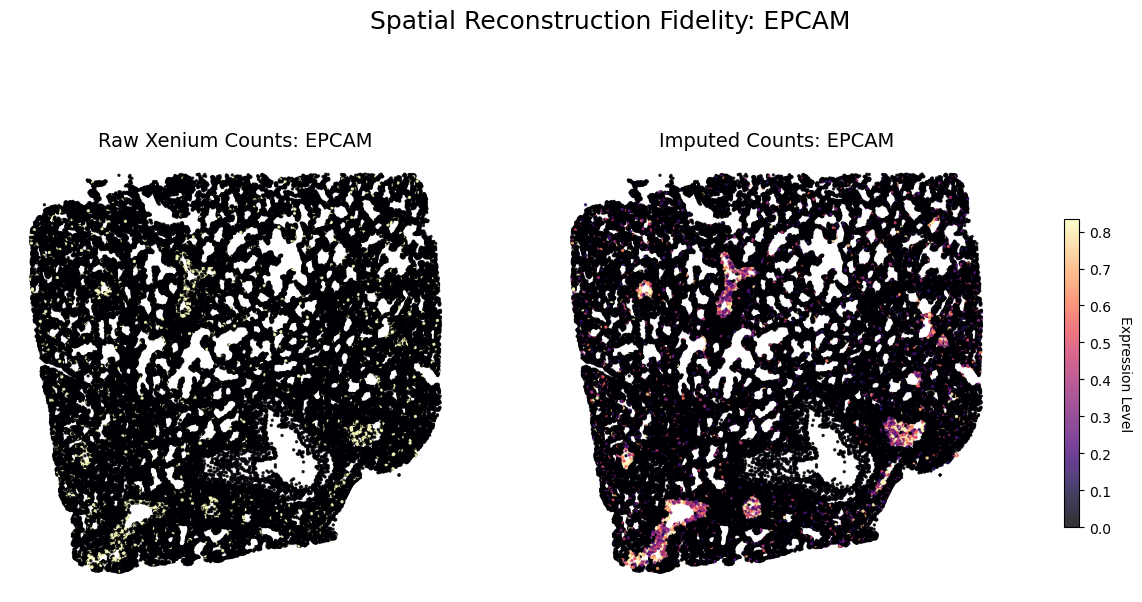

In [97]:
import matplotlib.pyplot as plt
import numpy as np

def plot_spatial_imputation(gene_symbol, var_names, spatial_coords, actual_matrix, imputed_matrix):
    """
    Generates a side-by-side spatial plot of Raw vs. Imputed expression.
    """
    # 1. Find the gene index
    # (Assuming var_names might have suffixes like 'PECAM1-1', we do a partial match)
    gene_idx = next((i for i, g in enumerate(var_names) if gene_symbol in g), None)
    
    if gene_idx is None:
        print(f"Gene '{gene_symbol}' not found in the Prime panel.")
        return
        
    actual_expr = actual_matrix[:, gene_idx]
    imputed_expr = imputed_matrix[:, gene_idx]
    
    x_coords = spatial_coords[:, 0]
    y_coords = spatial_coords[:, 1]
    
    # 2. Setup the figure
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    # Define common color scale limits to ensure fair visual comparison
    vmax = np.percentile(imputed_expr, 99) 
    vmin = 0
    
    # Plot 1: Raw Xenium Data
    sc1 = axes[0].scatter(x_coords, y_coords, c=actual_expr, cmap='magma', s=2, alpha=0.8, vmin=vmin, vmax=vmax)
    axes[0].set_title(f"Raw Xenium Counts: {gene_symbol}", fontsize=14)
    axes[0].set_aspect('equal')
    axes[0].axis('off')
    
    # Plot 2: XenImpute Data
    sc2 = axes[1].scatter(x_coords, y_coords, c=imputed_expr, cmap='magma', s=2, alpha=0.8, vmin=vmin, vmax=vmax)
    axes[1].set_title(f"Imputed Counts: {gene_symbol}", fontsize=14)
    axes[1].set_aspect('equal')
    axes[1].axis('off')
    
    cbar = plt.colorbar(sc2, ax=axes.ravel().tolist(), shrink=0.5)
    cbar.set_label('Expression Level', rotation=270, labelpad=15)
    
    plt.suptitle(f"Spatial Reconstruction Fidelity: {gene_symbol}", fontsize=18, y=0.95)
    plt.show()

# --- EXECUTION ---
# Grab the spatial coordinates from your AnnData object (adjust 'adata_v1' if named differently)
coords = adata_v1.obsm['spatial'] 
gene_names = adata_prime.var_names

# Test it on a highly specific structural/marker gene
target_gene = "EPCAM" # Endothelial marker, should map the capillary network
plot_spatial_imputation(target_gene, gene_names, coords, target_matrix, pred_matrix)

In [95]:
gene_names

Index(['A2ML1-prime-with-v1-seg', 'AAMP-prime-with-v1-seg',
       'AAR2-prime-with-v1-seg', 'AARSD1-prime-with-v1-seg',
       'ABAT-prime-with-v1-seg', 'ABCA1-prime-with-v1-seg',
       'ABCA3-prime-with-v1-seg', 'ABCA4-prime-with-v1-seg',
       'ABCA7-prime-with-v1-seg', 'ABCB1-prime-with-v1-seg',
       ...
       'ZPR1-prime-with-v1-seg', 'ZSCAN1-prime-with-v1-seg',
       'ZSCAN12-prime-with-v1-seg', 'ZSCAN16-prime-with-v1-seg',
       'ZSCAN20-prime-with-v1-seg', 'ZSCAN26-prime-with-v1-seg',
       'ZSWIM6-prime-with-v1-seg', 'ZUP1-prime-with-v1-seg',
       'ZYG11B-prime-with-v1-seg', 'ZYX-prime-with-v1-seg'],
      dtype='object', length=5001)

In [98]:
import torch
import numpy as np
from sklearn.neighbors import NearestNeighbors

# Assuming adata_v1 is already loaded in your local test script
spatial_coords = adata_v1.obsm['spatial']
cluster_labels = adata_v1.obs['v1_cluster_identity'].cat.codes.values
cluster_tensor = torch.tensor(cluster_labels, dtype=torch.long)
total_cells = spatial_coords.shape[0]

radii_to_test = [15.0, 30.0, 50.0, 100.0]

print(f"--- SPATIAL RADIUS DIAGNOSTIC ---")
print(f"Total Cells in Core: {total_cells:,}\n")

for r in radii_to_test:
    # 1. Build Base Spatial Graph
    nn_model = NearestNeighbors(radius=r, algorithm='kd_tree')
    nn_model.fit(spatial_coords)
    adj_matrix = nn_model.radius_neighbors_graph(spatial_coords, mode='connectivity').tocoo()
    
    row = torch.tensor(adj_matrix.row, dtype=torch.long)
    col = torch.tensor(adj_matrix.col, dtype=torch.long)
    snn_edge_index = torch.stack([row, col], dim=0)
    
    # 2. Apply Biological Firewall
    homophilic_mask = cluster_tensor[row] == cluster_tensor[col]
    ctasnn_edge_index = snn_edge_index[:, homophilic_mask]
    
    # 3. Calculate Orphans
    # torch.unique returns all nodes that have at least one valid edge
    if ctasnn_edge_index.numel() > 0:
        connected_nodes = torch.unique(ctasnn_edge_index).size(0)
    else:
        connected_nodes = 0
        
    orphan_count = total_cells - connected_nodes
    orphan_percentage = (orphan_count / total_cells) * 100
    
    print(f"Radius: {r} Microns")
    print(f"  -> Total Spatial Edges:   {snn_edge_index.shape[1]:,}")
    print(f"  -> Pruned ctaSNN Edges:   {ctasnn_edge_index.shape[1]:,}")
    print(f"  -> Orphan Cells Isolated: {orphan_count:,} ({orphan_percentage:.1f}%)")
    print("-" * 50)

--- SPATIAL RADIUS DIAGNOSTIC ---
Total Cells in Core: 99,992

Radius: 15.0 Microns
  -> Total Spatial Edges:   878,004
  -> Pruned ctaSNN Edges:   196,502
  -> Orphan Cells Isolated: 0 (0.0%)
--------------------------------------------------
Radius: 30.0 Microns
  -> Total Spatial Edges:   3,030,782
  -> Pruned ctaSNN Edges:   402,674
  -> Orphan Cells Isolated: 0 (0.0%)
--------------------------------------------------
Radius: 50.0 Microns
  -> Total Spatial Edges:   7,542,500
  -> Pruned ctaSNN Edges:   790,752
  -> Orphan Cells Isolated: 0 (0.0%)
--------------------------------------------------
Radius: 100.0 Microns
  -> Total Spatial Edges:   26,515,082
  -> Pruned ctaSNN Edges:   2,246,294
  -> Orphan Cells Isolated: 0 (0.0%)
--------------------------------------------------
